# 🧩 Student Heterogeneous Group Formation

This notebook implements a system to form balanced student teams based on complementary skill profiles. The goal is to create heterogeneous groups where students with different strengths and weaknesses can work together effectively and learn from each other.

## Overview

The system focuses on creating balanced groups across several key skill domains:

- **Soft Skills**: Communication, leadership, teamwork, adaptability
- **Hard Skills**: Technical knowledge, programming, analysis, domain-specific abilities
- **Creativity**: Innovation, idea generation, thinking outside the box
- **Teamwork**: Collaboration, conflict resolution, task coordination

## Approach

1. **Data Preparation**: Load and preprocess student skill profiles
2. **Skill Profile Analysis**: Understand the distribution of skills across the student population
3. **Clustering for Skill Patterns**: Identify common skill patterns among students 
4. **Group Formation Algorithm**: Create heterogeneous groups with complementary skills
5. **Group Analysis**: Evaluate the balance and complementarity of formed groups

In [1]:
# Import required libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
from IPython.display import HTML, display
import random
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Suppress warnings
warnings.filterwarnings('ignore')

# Set visualization styles
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Data Loading and Exploration

First, we'll load the student dataset and explore its structure. The dataset contains student scores across different skill categories.

In [2]:
# Define data path
data_folder = 'data'
student_data_path = os.path.join(data_folder, 'students_dataset.csv')

# Load the data
def load_student_data(filepath):
    try:
        df = pd.read_csv(filepath)
        print(f"✅ Successfully loaded data with {len(df)} student records")
        return df
    except FileNotFoundError:
        print(f"❌ File not found: {filepath}")
        print("Please ensure the data file exists in the specified path.")
        return None
    except Exception as e:
        print(f"❌ Error loading data: {e}")
        return None

# Load student data
students_df = load_student_data(student_data_path)

# Display the first few rows if data loaded successfully
if students_df is not None:
    print("\nFirst 5 rows of the dataset:")
    display(students_df.head())
    
    # Show basic dataset information
    print("\nDataset information:")
    print(f"Number of students: {len(students_df)}")
    print(f"Number of features: {len(students_df.columns)}")
    print("\nFeatures:")
    display(pd.DataFrame({'Column Name': students_df.columns, 
                         'Data Type': students_df.dtypes}))
    
    # Check for missing values
    missing = students_df.isnull().sum()
    if missing.sum() > 0:
        print("\nMissing values per column:")
        display(missing[missing > 0])
    else:
        print("\nNo missing values found in the dataset.")

✅ Successfully loaded data with 3600 student records

First 5 rows of the dataset:


,first_name,last_name,gender,age,nationality,hard_skills,soft_skills,teamwork,creativity,class
0,Michel,Tchinda,Male,22,Cameroonian,0.02,3.51,4.98,1.67,3B88
1,Skander,Mejri,Male,36,Tunisian,3.18,0.02,4.52,2.65,3B88
2,Ousmane,Ba,Male,24,Senegalese,2.71,3.69,0.29,1.65,3B88
3,Mourad,Zouari,Male,25,Tunisian,1.78,1.15,0.85,2.21,3B88
4,Hatem,Zouari,Male,19,Tunisian,3.44,4.07,2.30,1.63,3B88



Dataset information:
Number of students: 3600
Number of features: 10

Features:


,Column Name,Data Type
first_name,first_name,object
last_name,last_name,object
gender,gender,object
age,age,int64
nationality,nationality,object
hard_skills,hard_skills,float64
soft_skills,soft_skills,float64
teamwork,teamwork,float64
creativity,creativity,float64
class,class,object



No missing values found in the dataset.


Detected skill columns: ['hard_skills', 'soft_skills', 'teamwork', 'creativity']

Summary statistics for skill scores:


,hard_skills,soft_skills,teamwork,creativity
count,3600.000000,3600.000000,3600.000000,3600.000000
mean,2.492150,2.468881,2.492083,2.484464
std,1.447433,1.440054,1.428254,1.432852
min,0.000000,0.000000,0.000000,0.000000
25%,1.230000,1.190000,1.240000,1.260000
50%,2.490000,2.485000,2.500000,2.465000
75%,3.740000,3.700000,3.710000,3.720000
max,5.000000,5.000000,5.000000,4.990000


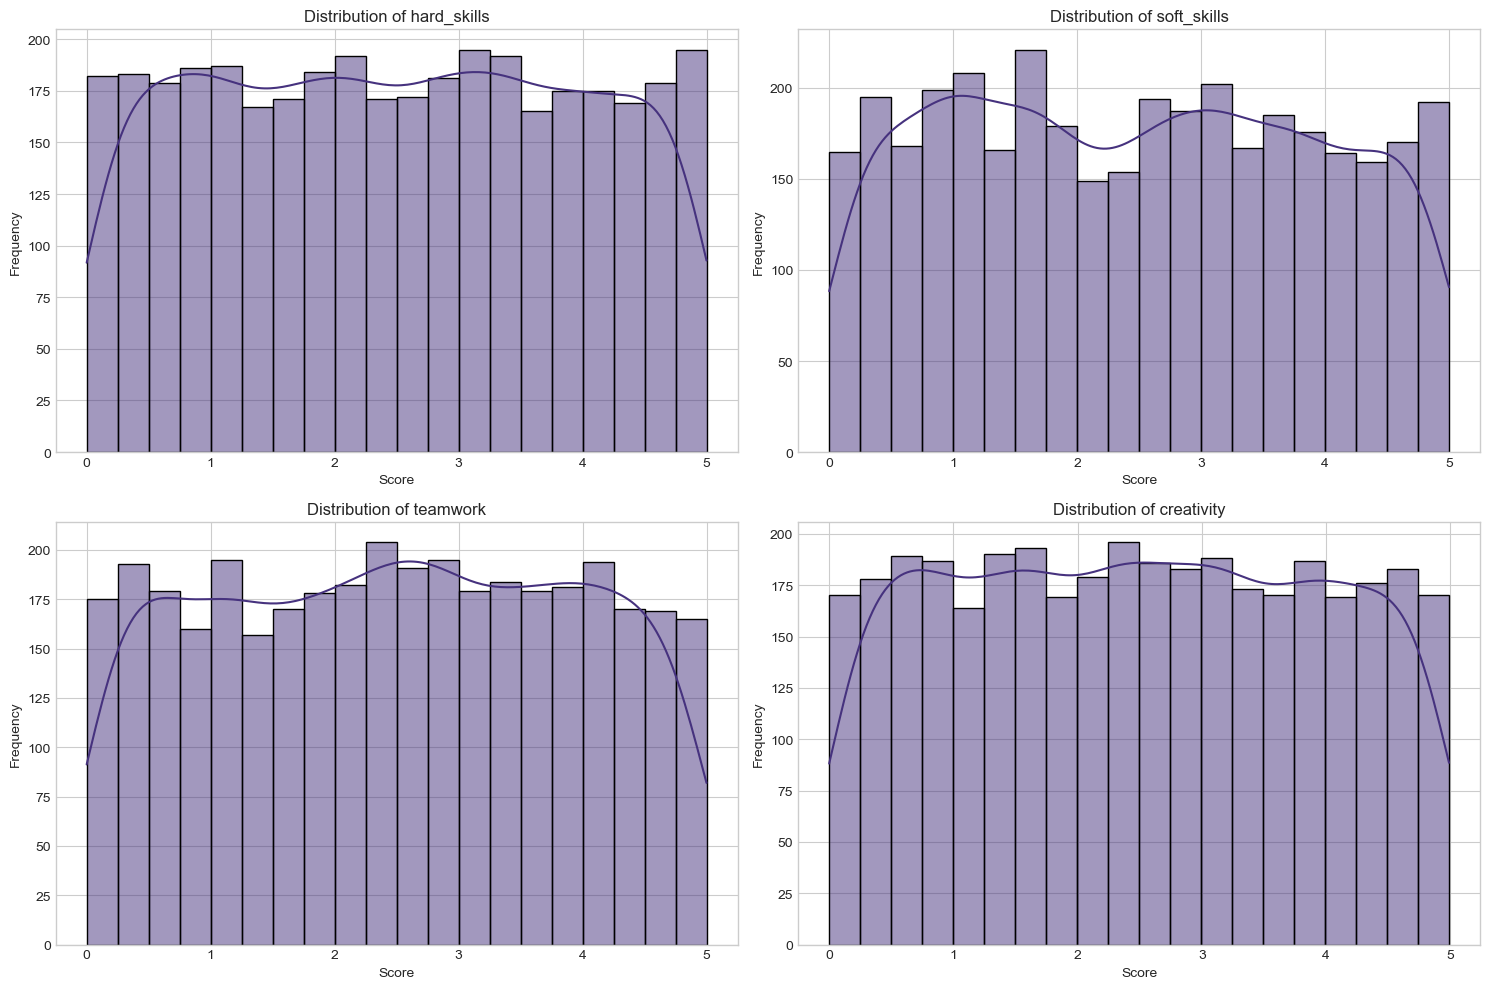

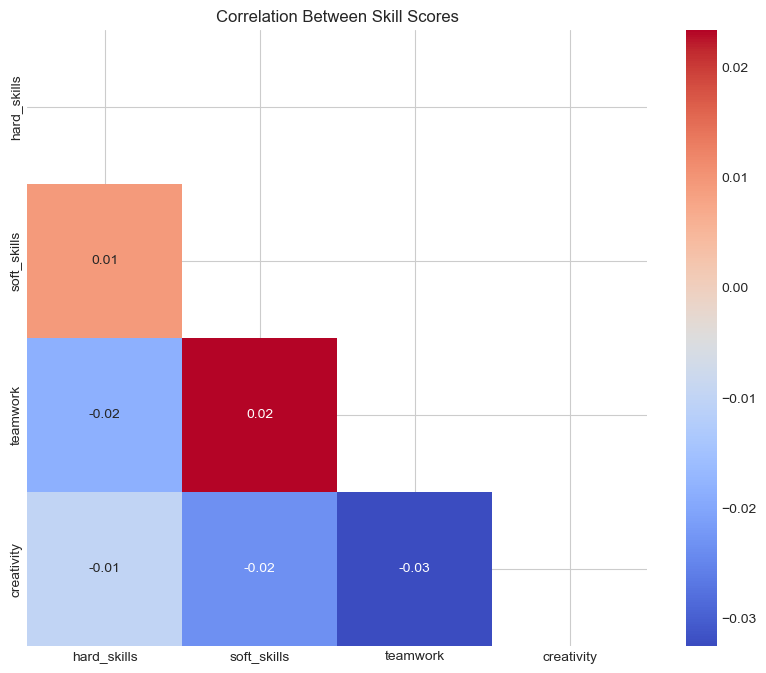

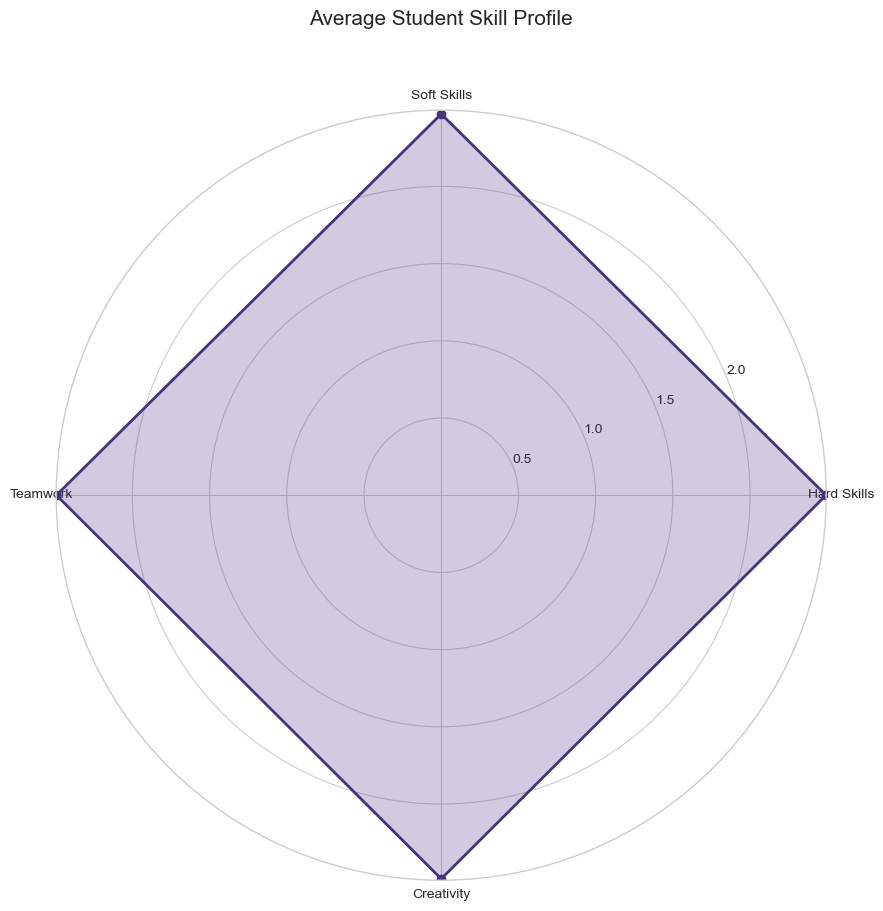

In [3]:
# Explore the distribution of scores
if students_df is not None:
    # Get skill columns (assuming they end with 'skills' or 'score')
    skill_cols = [col for col in students_df.columns if 
                  any(x in col.lower() for x in ['skill', 'score', 'creativity', 'teamwork'])]
    
    if not skill_cols:
        print("No skill columns detected. Please check column naming.")
    else:
        print(f"Detected skill columns: {skill_cols}")
        
        # Display summary statistics
        print("\nSummary statistics for skill scores:")
        display(students_df[skill_cols].describe())
        
        # Create histograms for skill score distributions
        plt.figure(figsize=(15, 10))
        
        for i, col in enumerate(skill_cols, 1):
            plt.subplot(2, (len(skill_cols)+1)//2, i)
            sns.histplot(students_df[col], kde=True, bins=20)
            plt.title(f'Distribution of {col}')
            plt.xlabel('Score')
            plt.ylabel('Frequency')
            
        plt.tight_layout()
        plt.show()
        
        # Create correlation heatmap
        plt.figure(figsize=(10, 8))
        corr = students_df[skill_cols].corr()
        mask = np.triu(np.ones_like(corr, dtype=bool))
        sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', mask=mask)
        plt.title('Correlation Between Skill Scores')
        plt.show()
        
        # Create a radar chart for the average skill profile
        def create_radar_chart(df, skill_columns, title="Skill Profile"):
            # Calculate mean values for each skill
            means = df[skill_columns].mean().values
            
            # For radar chart, we need to close the circle
            values = np.append(means, means[0])
            
            # Create angle values
            N = len(means)
            angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
            angles += angles[:1]  # Close the loop
            
            # Create labels (prettify column names)
            labels = [col.replace('_', ' ').title() for col in skill_columns]
            labels += labels[:1]  # Close the loop
            
            # Create the plot
            fig = plt.figure(figsize=(10, 10))
            ax = fig.add_subplot(111, polar=True)
            
            # Draw the radar chart
            ax.plot(angles, values, 'o-', linewidth=2)
            ax.fill(angles, values, alpha=0.25)
            
            # Set the labels
            ax.set_thetagrids(np.degrees(angles[:-1]), labels[:-1])
            
            # Beautify
            ax.set_title(title, size=15, y=1.1)
            ax.grid(True)
            
            return fig
        
        # Create radar chart for average student
        radar_fig = create_radar_chart(students_df, skill_cols, "Average Student Skill Profile")
        plt.show()

## 2. Data Preprocessing

Before clustering, we'll preprocess the data to ensure it's suitable for analysis. This includes:
1. Handling missing values (if any)
2. Scaling the features to ensure all skills contribute equally
3. Calculating additional metrics like overall skill level and skill variance

Adding derived features...
  - Added overall_skill (mean of all skills)
  - Added skill_variance (variance across skills)
  - Added dominant_skill (strongest skill area)
  - Added weakest_skill (area needing most development)
Normalizing skill scores...
  - Added normalized versions of all skill columns

Processed data (first 5 rows):


,first_name,last_name,gender,age,nationality,hard_skills,soft_skills,teamwork,creativity,class,overall_skill,skill_variance,dominant_skill,weakest_skill,norm_hard_skills,norm_soft_skills,norm_teamwork,norm_creativity
0,Michel,Tchinda,Male,22,Cameroonian,0.02,3.51,4.98,1.67,3B88,2.5450,4.667233,teamwork,hard_skills,0.004,0.702,0.996,0.334669
1,Skander,Mejri,Male,36,Tunisian,3.18,0.02,4.52,2.65,3B88,2.5925,3.560492,teamwork,soft_skills,0.636,0.004,0.904,0.531062
2,Ousmane,Ba,Male,24,Senegalese,2.71,3.69,0.29,1.65,3B88,2.0850,2.125967,soft_skills,teamwork,0.542,0.738,0.058,0.330661
3,Mourad,Zouari,Male,25,Tunisian,1.78,1.15,0.85,2.21,3B88,1.4975,0.375825,creativity,teamwork,0.356,0.230,0.170,0.442886
4,Hatem,Zouari,Male,19,Tunisian,3.44,4.07,2.30,1.63,3B88,2.8600,1.209000,soft_skills,creativity,0.688,0.814,0.460,0.326653



Summary of derived features:


,overall_skill,skill_variance
count,3600.000000,3600.000000
mean,2.484394,2.082707
std,0.709277,1.273180
min,0.200000,0.019892
25%,1.997500,1.037235
50%,2.492500,1.922563
75%,2.972500,2.940723
max,4.555000,6.643825


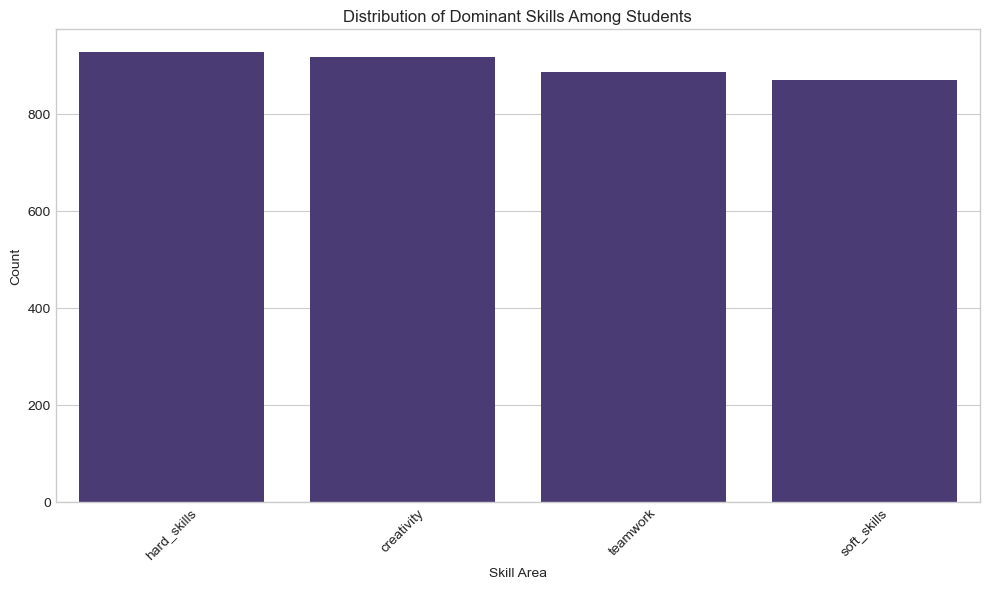

In [4]:
# Preprocess the student data
def preprocess_student_data(df, skill_columns):
    """
    Preprocess student data for clustering.
    
    Args:
        df: DataFrame containing student data
        skill_columns: List of columns containing skill scores
        
    Returns:
        Processed DataFrame ready for clustering
    """
    # Create a copy to avoid modifying the original
    processed_df = df.copy()
    
    # Handle missing values if any
    if processed_df[skill_columns].isnull().sum().sum() > 0:
        print("Handling missing values...")
        # Fill missing values with mean of the column
        for col in skill_columns:
            if processed_df[col].isnull().sum() > 0:
                mean_val = processed_df[col].mean()
                processed_df[col] = processed_df[col].fillna(mean_val)
                print(f"  - Filled missing values in {col} with mean: {mean_val:.2f}")
    
    # Add derived features
    print("Adding derived features...")
    
    # Overall skill level (average across all skills)
    processed_df['overall_skill'] = processed_df[skill_columns].mean(axis=1)
    print(f"  - Added overall_skill (mean of all skills)")
    
    # Skill variance (how specialized or balanced a student is)
    processed_df['skill_variance'] = processed_df[skill_columns].var(axis=1)
    print(f"  - Added skill_variance (variance across skills)")
    
    # Dominant skill area
    processed_df['dominant_skill'] = processed_df[skill_columns].idxmax(axis=1)
    print(f"  - Added dominant_skill (strongest skill area)")
    
    # Weakest skill area
    processed_df['weakest_skill'] = processed_df[skill_columns].idxmin(axis=1)
    print(f"  - Added weakest_skill (area needing most development)")
    
    # Create normalized versions of the skills (0-1 scale)
    print("Normalizing skill scores...")
    scaler = MinMaxScaler()
    normalized_skills = scaler.fit_transform(processed_df[skill_columns])
    
    for i, col in enumerate(skill_columns):
        processed_df[f'norm_{col}'] = normalized_skills[:, i]
        
    print(f"  - Added normalized versions of all skill columns")
    
    return processed_df

# Apply preprocessing if data is loaded
if students_df is not None:
    # Get skill columns
    skill_cols = [col for col in students_df.columns if 
                  any(x in col.lower() for x in ['skill', 'score', 'creativity', 'teamwork'])]
    
    if skill_cols:
        # Preprocess the data
        processed_students = preprocess_student_data(students_df, skill_cols)
        
        # Display the processed data
        print("\nProcessed data (first 5 rows):")
        display(processed_students.head())
        
        # Show summary of derived features
        print("\nSummary of derived features:")
        derived_cols = ['overall_skill', 'skill_variance']
        display(processed_students[derived_cols].describe())
        
        # Display distribution of dominant skills
        plt.figure(figsize=(10, 6))
        dominant_counts = processed_students['dominant_skill'].value_counts()
        sns.barplot(x=dominant_counts.index, y=dominant_counts.values)
        plt.title('Distribution of Dominant Skills Among Students')
        plt.xlabel('Skill Area')
        plt.ylabel('Count')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
    else:
        print("No skill columns identified for preprocessing.")

## 3. Skill Pattern Identification through Clustering and Model Evaluation

Now we'll identify common patterns in student skill profiles using different clustering algorithms:
1. K-means clustering - to find centroids-based clusters
2. DBSCAN - to find density-based clusters that can handle irregular cluster shapes

We'll evaluate and compare these models using silhouette scores to determine which approach better captures the natural groupings in our student skill profiles.

In [5]:
# Function to perform clustering on student skill profiles
def cluster_student_skills(df, skill_columns, n_clusters=4):
    """
    Cluster students based on their skill profiles.
    
    Args:
        df: Processed DataFrame with student data
        skill_columns: List of columns containing skill scores
        n_clusters: Number of clusters to form
        
    Returns:
        DataFrame with cluster assignments
    """
    # Create a copy to avoid modifying the original
    clustered_df = df.copy()
    
    # Extract features for clustering (normalized skill scores)
    norm_cols = [f'norm_{col}' for col in skill_columns]
    if all(col in clustered_df.columns for col in norm_cols):
        X = clustered_df[norm_cols].values
    else:
        print("Normalized columns not found, using original skill columns")
        X = clustered_df[skill_columns].values
    
    # Scale the data to have mean=0 and variance=1
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Determine optimal number of clusters using elbow method
    wcss = []  # Within-Cluster Sum of Squares
    max_clusters = min(10, len(df) - 1)  # Don't try more clusters than data points minus 1
    
    print("Determining optimal number of clusters...")
    for i in range(1, max_clusters + 1):
        kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
        kmeans.fit(X_scaled)
        wcss.append(kmeans.inertia_)
    
    # Plot elbow method results
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, max_clusters + 1), wcss, marker='o', linestyle='-')
    plt.title('Elbow Method for Optimal k')
    plt.xlabel('Number of Clusters')
    plt.ylabel('WCSS')
    plt.grid(True)
    plt.show()
    
    # Calculate silhouette scores for different k values
    silhouette_scores = []
    print("\nCalculating silhouette scores for different cluster numbers...")
    for i in range(2, max_clusters + 1):  # Silhouette score needs at least 2 clusters
        kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
        cluster_labels = kmeans.fit_predict(X_scaled)
        
        # Calculate silhouette score
        from sklearn.metrics import silhouette_score
        if len(set(cluster_labels)) > 1:  # Ensure we have at least 2 clusters with data points
            score = silhouette_score(X_scaled, cluster_labels)
            silhouette_scores.append(score)
        else:
            silhouette_scores.append(0)
    
    # Plot silhouette scores
    plt.figure(figsize=(10, 6))
    plt.plot(range(2, max_clusters + 1), silhouette_scores, marker='o', linestyle='-')
    plt.title('Silhouette Score Method for Optimal k')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Silhouette Score (higher is better)')
    plt.grid(True)
    plt.show()
    
    # Find the k with the best silhouette score
    best_k_silhouette = silhouette_scores.index(max(silhouette_scores)) + 2  # +2 because we started from 2
    print(f"\nBest k according to silhouette score: {best_k_silhouette} (score: {max(silhouette_scores):.4f})")
    print(f"Selected k for clustering: {n_clusters}")
    
    # Proceed with the specified number of clusters
    print(f"\nPerforming K-means clustering with {n_clusters} clusters...")
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', max_iter=300, n_init=10, random_state=42)
    clustered_df['cluster'] = kmeans.fit_predict(X_scaled)
    
    # Calculate silhouette score for the selected number of clusters
    silhouette_avg = silhouette_score(X_scaled, clustered_df['cluster'])
    print(f"Silhouette Score for {n_clusters} clusters: {silhouette_avg:.4f}")
    
    # Get cluster centers (in the original scale)
    centers_scaled = kmeans.cluster_centers_
    centers_original = scaler.inverse_transform(centers_scaled)
    
    # Create a DataFrame for cluster centers
    if all(col in clustered_df.columns for col in norm_cols):
        centers_df = pd.DataFrame(centers_original, columns=norm_cols)
        # Rename columns back to original
        centers_df.columns = [col.replace('norm_', '') for col in centers_df.columns]
    else:
        centers_df = pd.DataFrame(centers_original, columns=skill_columns)
    
    centers_df['cluster'] = range(n_clusters)
    
    return clustered_df, centers_df, X_scaled, silhouette_avg

In [6]:
# Function to visualize the clusters
def visualize_clusters(clustered_df, cluster_centers_df, skill_columns):
    """
    Visualize the clusters of student skill profiles.
    
    Args:
        clustered_df: DataFrame with cluster assignments
        cluster_centers_df: DataFrame with cluster centers
        skill_columns: List of columns containing skill scores
    """
    # Get number of clusters
    n_clusters = cluster_centers_df['cluster'].nunique()
    print(f"Visualizing {n_clusters} clusters...")
    
    # 1. Show cluster distribution
    plt.figure(figsize=(10, 6))
    cluster_counts = clustered_df['cluster'].value_counts().sort_index()
    sns.barplot(x=cluster_counts.index, y=cluster_counts.values)
    plt.title('Distribution of Students Across Clusters')
    plt.xlabel('Cluster')
    plt.ylabel('Number of Students')
    plt.grid(True, axis='y')
    plt.show()
    
    # 2. Visualize cluster centers as radar charts
    fig, axes = plt.subplots(nrows=(n_clusters+1)//2, ncols=2, 
                           figsize=(15, 5*((n_clusters+1)//2)), 
                           subplot_kw={'polar': True})
    
    # Ensure axes is always a flattened array
    axes = np.atleast_1d(axes).flatten()
    
    # Create radar charts for each cluster
    for i in range(n_clusters):
        # Get the skill values for this cluster center
        values = [cluster_centers_df.loc[cluster_centers_df['cluster'] == i, skill].values[0] 
                 for skill in skill_columns]
        
        # Close the loop for the radar chart
        values = np.append(values, values[0])
        
        # Angles for the radar chart
        angles = np.linspace(0, 2*np.pi, len(skill_columns), endpoint=False).tolist()
        angles += angles[:1]  # Close the loop
        
        # Labels (prettify column names)
        labels = [col.replace('_', ' ').title() for col in skill_columns]
        labels += labels[:1]  # Close the loop
        
        # Plot the radar chart
        axes[i].plot(angles, values, 'o-', linewidth=2)
        axes[i].fill(angles, values, alpha=0.25)
        axes[i].set_thetagrids(np.degrees(angles[:-1]), labels[:-1])
        axes[i].set_title(f'Cluster {i}: Skill Profile', size=15)
    
    # Hide any unused subplots
    for i in range(n_clusters, len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # 3. Use PCA to visualize clusters in 2D
    # Extract features for visualization
    X = clustered_df[skill_columns].values
    
    # Apply PCA to reduce dimensions to 2D
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    
    # Create a DataFrame for plotting
    pca_df = pd.DataFrame({
        'PCA1': X_pca[:, 0],
        'PCA2': X_pca[:, 1],
        'Cluster': clustered_df['cluster']
    })
    
    # Plot the clusters
    plt.figure(figsize=(12, 8))
    sns.scatterplot(data=pca_df, x='PCA1', y='PCA2', hue='Cluster', 
                   palette='viridis', s=100, alpha=0.7)
    plt.title('Student Clusters Visualized with PCA')
    plt.grid(True)
    plt.show()
    
    # 4. Show summary statistics for each cluster
    print("\nCluster summary statistics:")
    for i in range(n_clusters):
        cluster_students = clustered_df[clustered_df['cluster'] == i]
        print(f"\nCluster {i}: {len(cluster_students)} students")
        print("Average skill values:")
        avg_skills = cluster_students[skill_columns].mean()
        for skill, value in avg_skills.items():
            print(f"  - {skill}: {value:.2f}")

## 4. Heterogeneous Group Formation Algorithm

Now that we've identified the different skill patterns among students, we can form heterogeneous groups. The goal is to create groups where students complement each other's strengths and weaknesses.

In [12]:
# DBSCAN Clustering Implementation
def apply_dbscan_clustering(X_scaled, skill_columns):
    """
    Apply DBSCAN clustering to the scaled student skill data.
    
    Args:
        X_scaled: Scaled feature matrix
        skill_columns: List of skill column names
    
    Returns:
        DataFrame with cluster assignments, silhouette score
    """
    from sklearn.cluster import DBSCAN
    from sklearn.metrics import silhouette_score
    import numpy as np
    
    print("Applying DBSCAN clustering...")
    
    # Find a good epsilon value using nearest neighbors
    from sklearn.neighbors import NearestNeighbors
    
    # Determine optimal eps parameter using k-distance graph
    neighbors = NearestNeighbors(n_neighbors=5)
    neighbors_fit = neighbors.fit(X_scaled)
    distances, indices = neighbors_fit.kneighbors(X_scaled)
    
    # Sort distances to find the 'elbow'
    distances = np.sort(distances[:, 4])  # 5th nearest neighbor
    
    # Plot k-distance graph
    plt.figure(figsize=(10, 6))
    plt.plot(distances)
    plt.title('K-distance Graph for DBSCAN eps Parameter Selection')
    plt.xlabel('Points (sorted by distance)')
    plt.ylabel('Distance to 5th nearest neighbor')
    plt.grid(True)
    plt.show()
    
    # Get a reasonable epsilon value from the 'elbow' point (approximately)
    # This is a heuristic approach - you might need to adjust this
    elbow_idx = np.argmax(np.diff(np.diff(distances))) + 1
    eps_value = distances[elbow_idx]
    print(f"Selected eps value: {eps_value:.4f} (from k-distance graph)")
    
    # Try a few different eps values around the estimated value
    eps_values = [eps_value * 0.75, eps_value, eps_value * 1.25]
    min_samples_values = [5]
    
    best_silhouette = -1
    best_eps = None
    best_min_samples = None
    best_labels = None
    
    for eps in eps_values:
        for min_samples in min_samples_values:
            # Apply DBSCAN
            dbscan = DBSCAN(eps=eps, min_samples=min_samples)
            labels = dbscan.fit_predict(X_scaled)
            
            # Count number of clusters (excluding noise points labeled as -1)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            
            # Calculate silhouette score if there are at least 2 clusters and no all-noise case
            if n_clusters >= 2 and len(set(labels)) > 1 and not all(l == -1 for l in labels):
                # Filter out noise points for silhouette calculation
                mask = labels != -1
                if sum(mask) > 1:  # Need at least 2 non-noise points
                    score = silhouette_score(X_scaled[mask], labels[mask])
                    print(f"DBSCAN with eps={eps:.4f}, min_samples={min_samples}: {n_clusters} clusters, silhouette={score:.4f}")
                    
                    if score > best_silhouette:
                        best_silhouette = score
                        best_eps = eps
                        best_min_samples = min_samples
                        best_labels = labels
            else:
                noise_count = sum(1 for l in labels if l == -1)
                total_count = len(labels)
                print(f"DBSCAN with eps={eps:.4f}, min_samples={min_samples}: {n_clusters} clusters, {noise_count}/{total_count} noise points")
    
    # If we couldn't find a good clustering, try with more lenient parameters
    if best_labels is None:
        print("\nRetrying with more lenient parameters...")
        dbscan = DBSCAN(eps=eps_value*1.5, min_samples=3)
        best_labels = dbscan.fit_predict(X_scaled)
        n_clusters = len(set(best_labels)) - (1 if -1 in best_labels else 0)
        best_eps = eps_value*1.5
        best_min_samples = 3
        
        # Calculate silhouette if possible
        if n_clusters >= 2:
            mask = best_labels != -1
            if sum(mask) > 1:
                best_silhouette = silhouette_score(X_scaled[mask], best_labels[mask])
            else:
                best_silhouette = 0
    
    print(f"\nBest DBSCAN parameters: eps={best_eps:.4f}, min_samples={best_min_samples}")
    print(f"Number of clusters: {len(set(best_labels)) - (1 if -1 in best_labels else 0)}")
    print(f"Silhouette score: {best_silhouette:.4f}")
    
    # Count noise points
    noise_count = sum(1 for l in best_labels if l == -1)
    print(f"Noise points: {noise_count} ({noise_count/len(best_labels)*100:.1f}%)")
    
    return best_labels, best_silhouette

Determining optimal number of clusters...


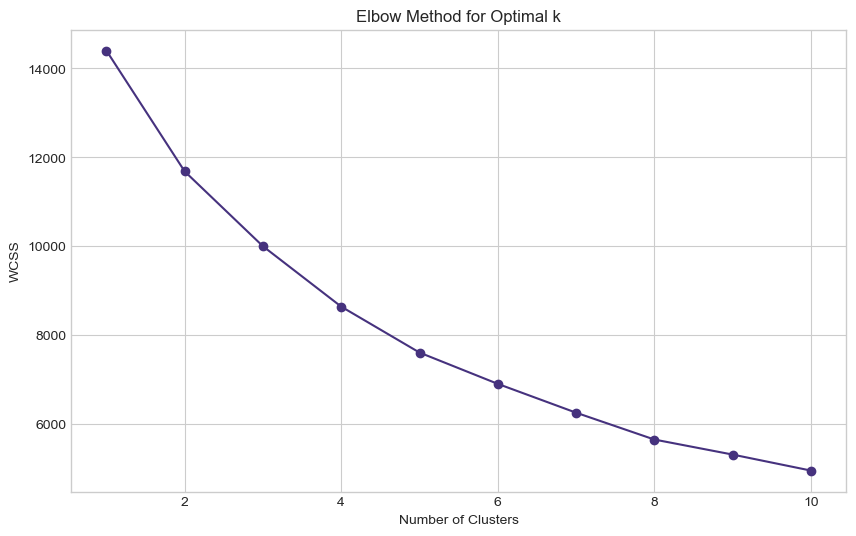


Calculating silhouette scores for different cluster numbers...


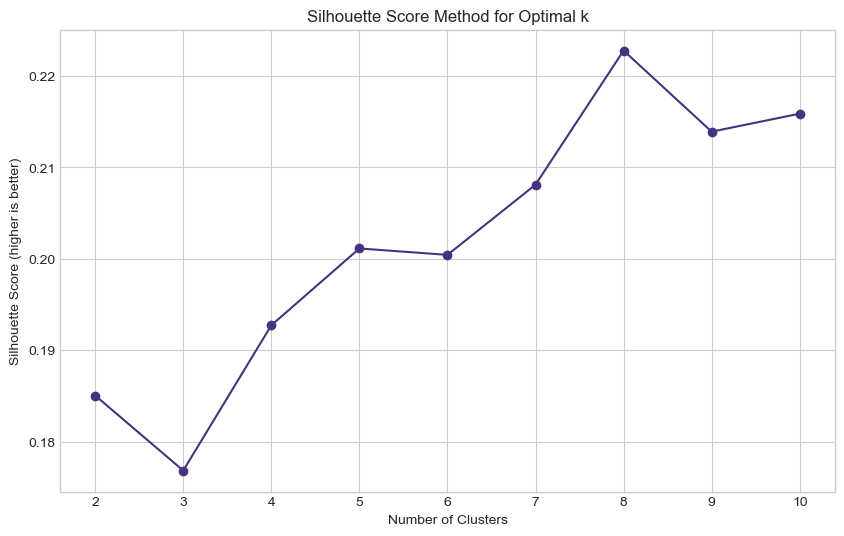


Best k according to silhouette score: 8 (score: 0.2228)
Selected k for clustering: 4

Performing K-means clustering with 4 clusters...
Silhouette Score for 4 clusters: 0.1927
Visualizing 4 clusters...


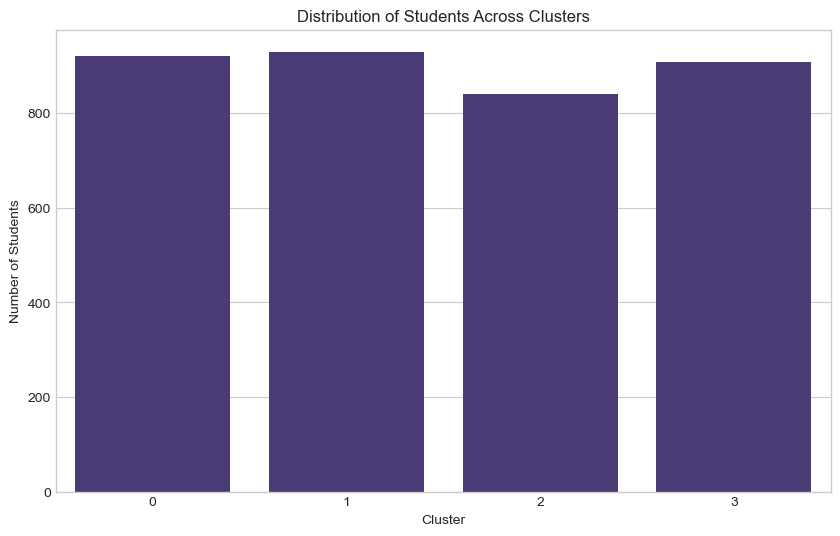

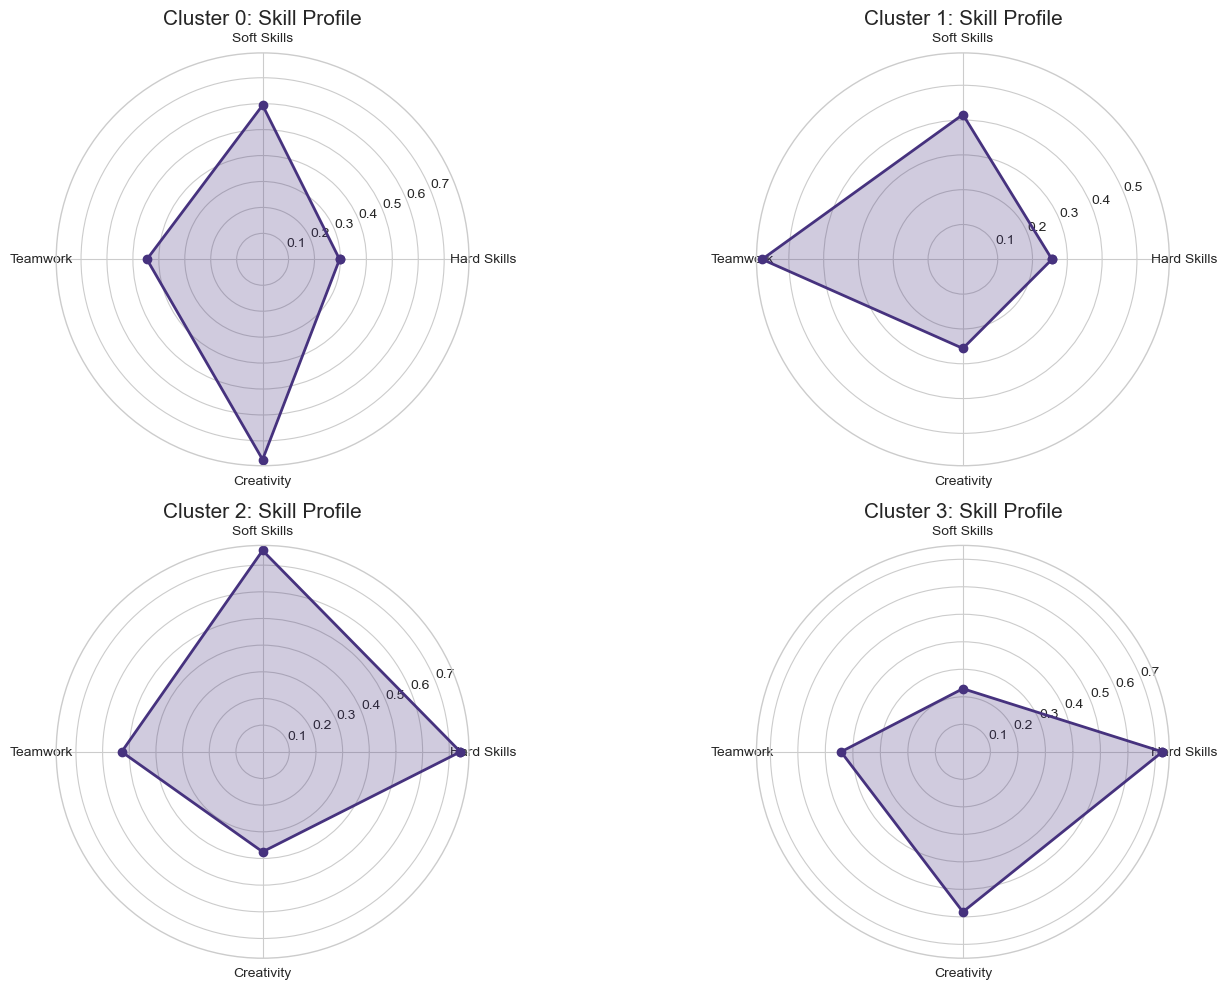

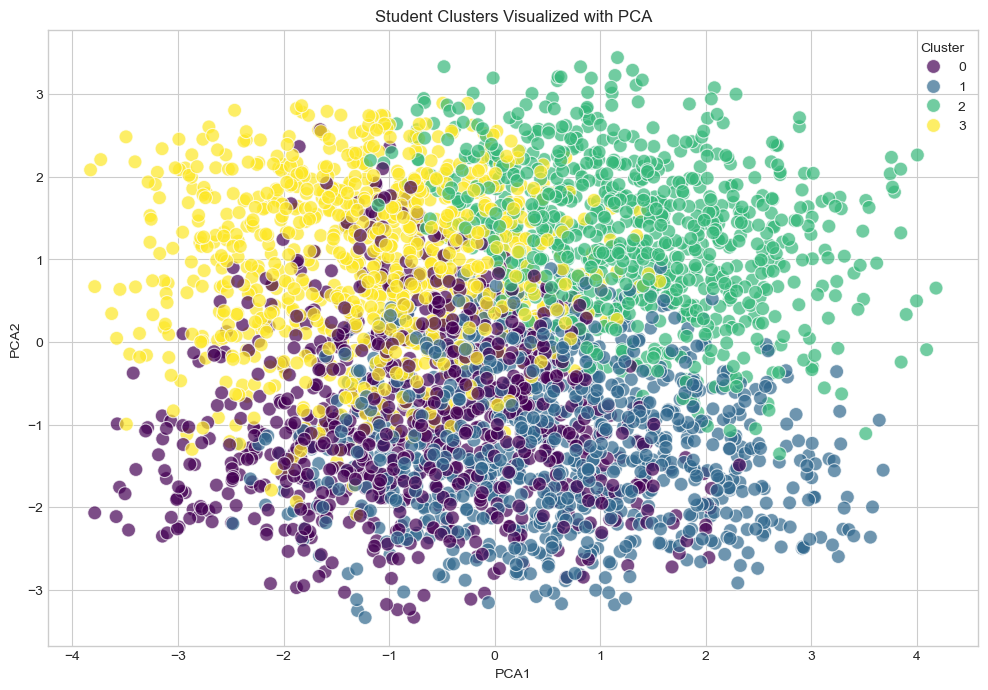


Cluster summary statistics:

Cluster 0: 920 students
Average skill values:
  - hard_skills: 1.48
  - soft_skills: 2.97
  - teamwork: 2.23
  - creativity: 3.85

Cluster 1: 930 students
Average skill values:
  - hard_skills: 1.28
  - soft_skills: 2.08
  - teamwork: 2.88
  - creativity: 1.28

Cluster 2: 841 students
Average skill values:
  - hard_skills: 3.71
  - soft_skills: 3.78
  - teamwork: 2.65
  - creativity: 1.87

Cluster 3: 909 students
Average skill values:
  - hard_skills: 3.63
  - soft_skills: 1.15
  - teamwork: 2.22
  - creativity: 2.90

Comparing K-means with DBSCAN clustering
Applying DBSCAN clustering...


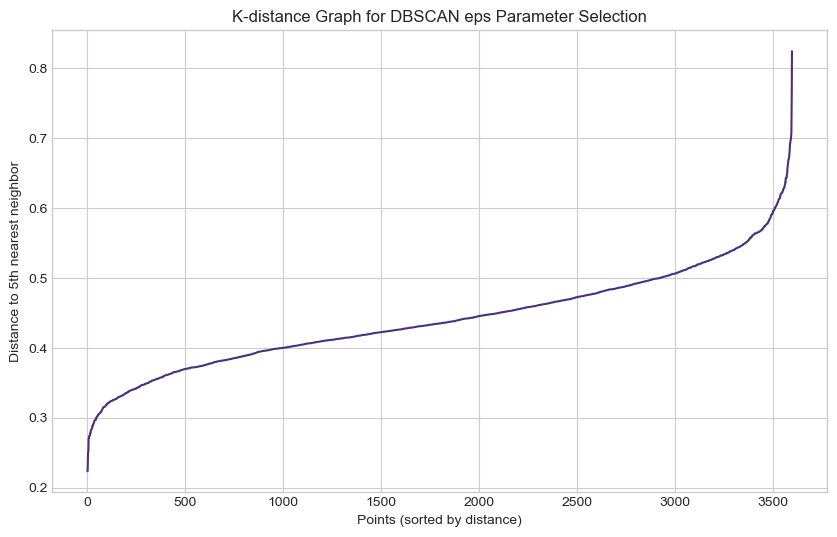

Selected eps value: 0.7674 (from k-distance graph)
DBSCAN with eps=0.5755, min_samples=5: 1 clusters, 13/3600 noise points
DBSCAN with eps=0.7674, min_samples=5: 1 clusters, 0/3600 noise points
DBSCAN with eps=0.9592, min_samples=5: 1 clusters, 0/3600 noise points

Retrying with more lenient parameters...

Best DBSCAN parameters: eps=1.1511, min_samples=3
Number of clusters: 1
Silhouette score: -1.0000
Noise points: 0 (0.0%)


<Figure size 1200x800 with 0 Axes>

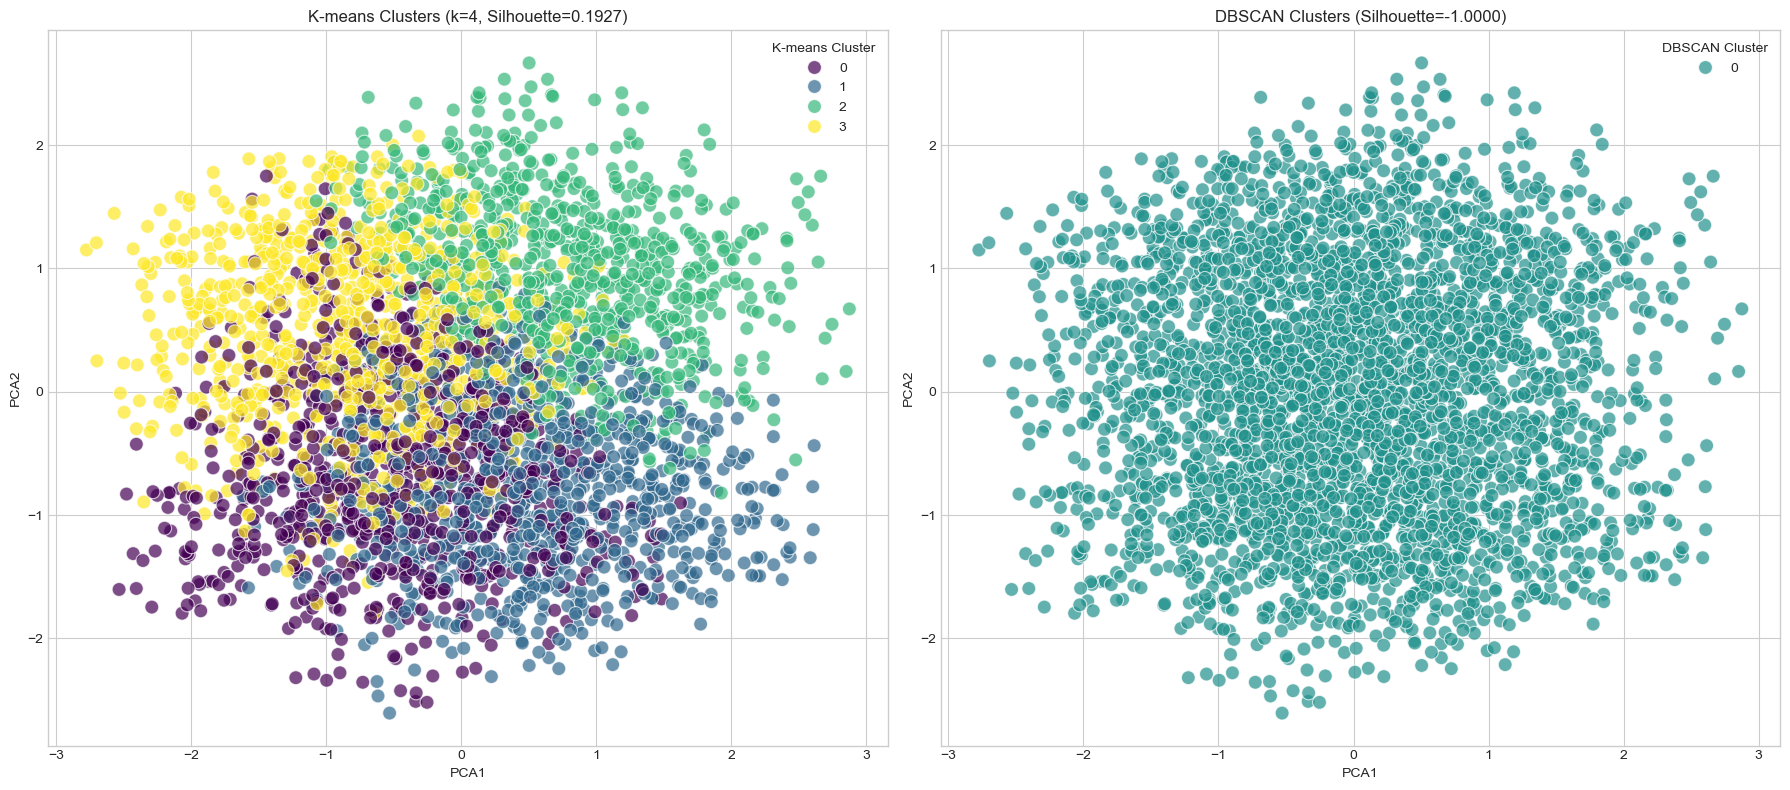


Clustering Comparison Summary:
K-means: 4 clusters, Silhouette Score: 0.1927
DBSCAN: 1 clusters, Silhouette Score: -1.0000

✅ K-means clustering performed better for this dataset.
Using K-means results for further analysis.


In [13]:
# Apply clustering algorithms and compare results
if 'processed_students' in locals():
    # Update the function call to capture the silhouette score
    n_clusters = 4  # Can be adjusted based on domain knowledge or silhouette plot
    clustered_students, cluster_centers, X_scaled, kmeans_silhouette = cluster_student_skills(processed_students, skill_cols, n_clusters)
    
    # Visualize the clusters
    visualize_clusters(clustered_students, cluster_centers, skill_cols)
    
    # Apply DBSCAN and compare results
    print("\n" + "="*50)
    print("Comparing K-means with DBSCAN clustering")
    print("="*50)
    
    # Apply DBSCAN
    dbscan_labels, dbscan_silhouette = apply_dbscan_clustering(X_scaled, skill_cols)
    
    # Add DBSCAN cluster assignments to the DataFrame
    clustered_students['dbscan_cluster'] = dbscan_labels
    
    # Visualize DBSCAN clusters using PCA
    plt.figure(figsize=(12, 8))
    
    # Apply PCA
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    # Create a DataFrame for plotting
    pca_df = pd.DataFrame({
        'PCA1': X_pca[:, 0],
        'PCA2': X_pca[:, 1],
        'K-means Cluster': clustered_students['cluster'],
        'DBSCAN Cluster': clustered_students['dbscan_cluster']
    })
    
    # Plot side by side comparison
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
    
    # K-means plot
    sns.scatterplot(data=pca_df, x='PCA1', y='PCA2', hue='K-means Cluster', 
                   palette='viridis', s=100, alpha=0.7, ax=ax1)
    ax1.set_title(f'K-means Clusters (k={n_clusters}, Silhouette={kmeans_silhouette:.4f})')
    ax1.grid(True)
    
    # DBSCAN plot
    # For DBSCAN, noise points are labeled -1
    noise_mask = pca_df['DBSCAN Cluster'] == -1
    non_noise_palette = 'viridis'
    
    # Plot non-noise points
    sns.scatterplot(data=pca_df[~noise_mask], x='PCA1', y='PCA2', 
                   hue='DBSCAN Cluster', palette=non_noise_palette, 
                   s=100, alpha=0.7, ax=ax2)
    
    # Add noise points in black
    if noise_mask.any():
        ax2.scatter(pca_df.loc[noise_mask, 'PCA1'], pca_df.loc[noise_mask, 'PCA2'], 
                   c='black', s=50, alpha=0.5, label='Noise')
    
    ax2.set_title(f'DBSCAN Clusters (Silhouette={dbscan_silhouette:.4f})')
    ax2.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Print comparison summary
    print("\nClustering Comparison Summary:")
    print(f"K-means: {n_clusters} clusters, Silhouette Score: {kmeans_silhouette:.4f}")
    dbscan_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    print(f"DBSCAN: {dbscan_clusters} clusters, Silhouette Score: {dbscan_silhouette:.4f}")
    
    # Determine which algorithm performed better based on silhouette score
    if kmeans_silhouette > dbscan_silhouette:
        print("\n✅ K-means clustering performed better for this dataset.")
        print("Using K-means results for further analysis.")
        # Keep using the original clusters for group formation
    else:
        print("\n✅ DBSCAN clustering performed better for this dataset.")
        print("Using DBSCAN results for further analysis.")
        # Update the cluster assignments to use DBSCAN results
        # Replace -1 (noise) with a new cluster number to handle them specially
        noise_cluster = dbscan_labels.max() + 1
        clustered_students['cluster'] = [label if label >= 0 else noise_cluster for label in dbscan_labels]

Forming 900 groups of 4 students each
Using COMPLEMENTARY grouping method: Pairing students with complementary skills


Analysis of 900 formed groups:
Group sizes: [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4

,hard_skills,soft_skills,teamwork,creativity,group
0,4.4700,4.5800,4.6150,4.3950,0
1,4.2050,4.8475,4.0025,4.4125,1
2,4.4550,4.3100,4.3950,3.9225,2
3,4.2700,4.3950,4.1800,3.9675,3
4,4.3075,3.7775,4.2550,4.3700,4
...,...,...,...,...,...
895,0.8100,0.5050,0.3550,1.1000,895
896,0.8650,0.8250,0.3425,0.6125,896
897,0.5800,0.6725,0.5375,0.5750,897
898,0.4875,0.6525,0.3875,0.4425,898


Creating multiple figures to display 900 groups (showing 10 per figure)


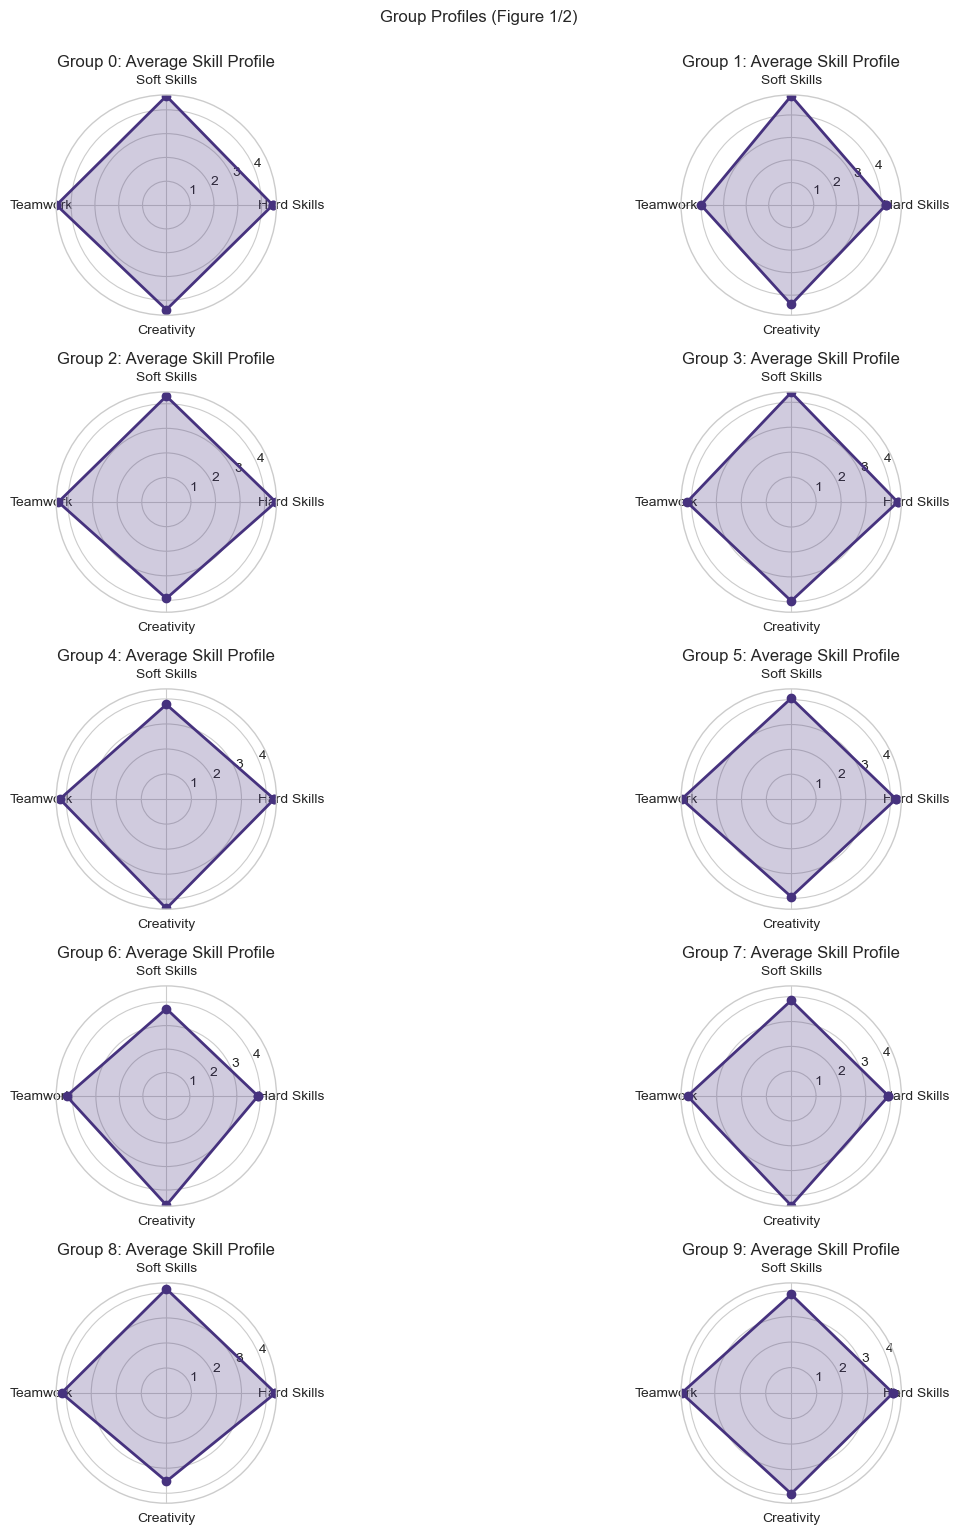

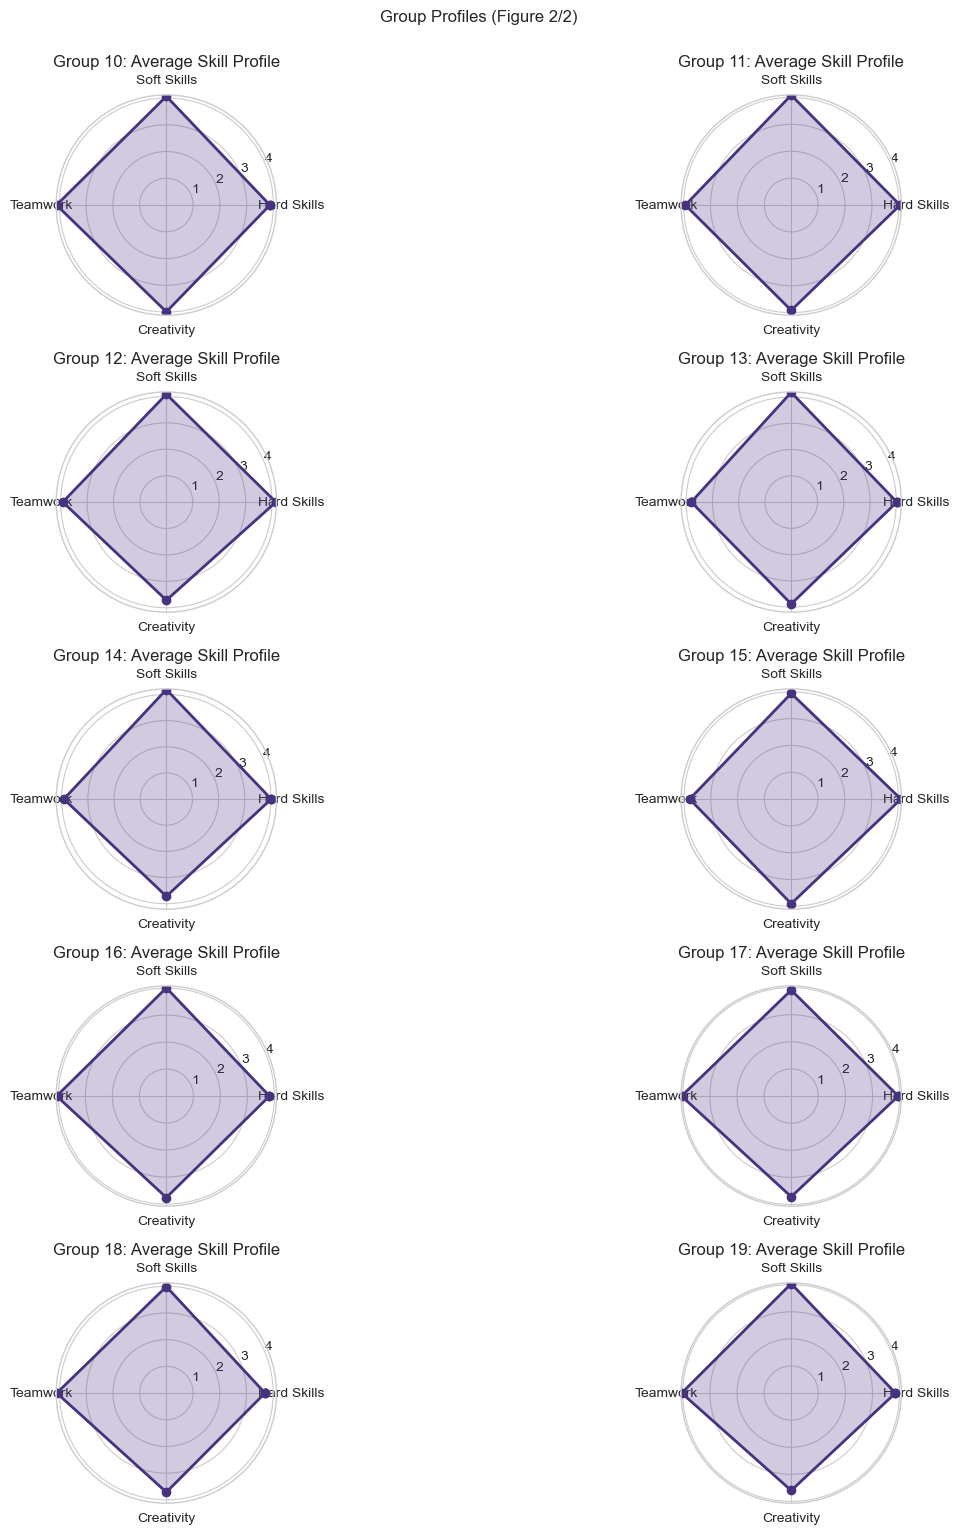

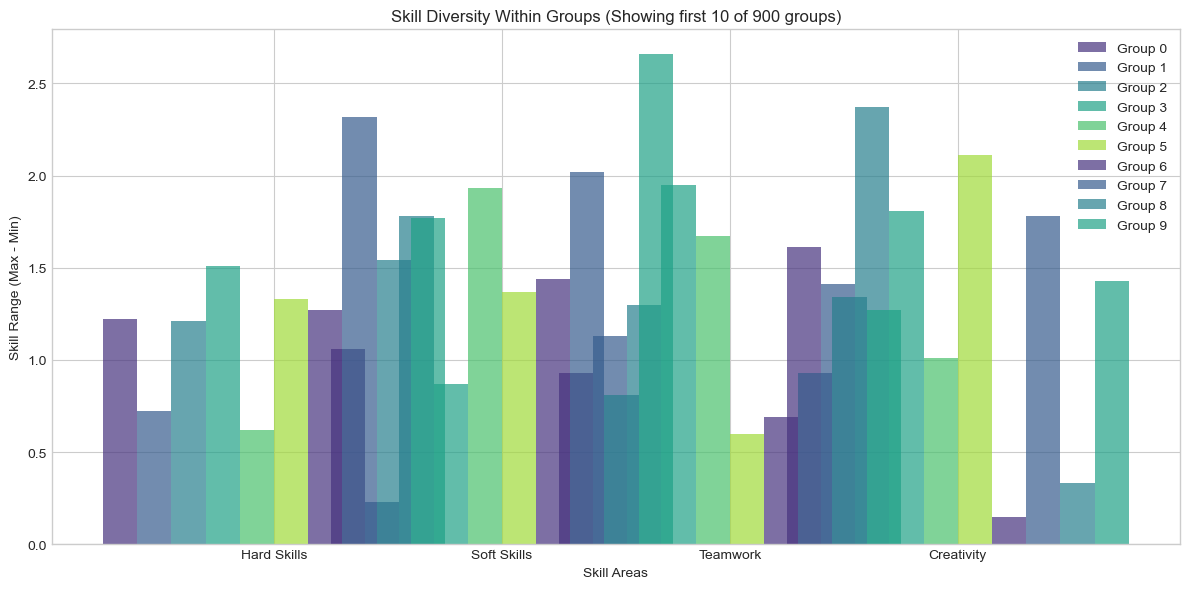


Detailed group profiles:

Summary of all groups:


,Group ID,Size,Avg Hard Skills,Avg Soft Skills,Avg Teamwork,Avg Creativity
0,0,4,4.4700,4.5800,4.6150,4.3950
1,1,4,4.2050,4.8475,4.0025,4.4125
2,2,4,4.4550,4.3100,4.3950,3.9225
3,3,4,4.2700,4.3950,4.1800,3.9675
4,4,4,4.3075,3.7775,4.2550,4.3700
...,...,...,...,...,...,...
895,895,4,0.8100,0.5050,0.3550,1.1000
896,896,4,0.8650,0.8250,0.3425,0.6125
897,897,4,0.5800,0.6725,0.5375,0.5750
898,898,4,0.4875,0.6525,0.3875,0.4425



Detailed profiles for first 5 groups:

Group 0 (4 members):
  Average skill profile:
    - Hard Skills: 4.47 (Range: 3.62 - 4.84)
    - Soft Skills: 4.58 (Range: 3.84 - 4.90)
    - Teamwork: 4.62 (Range: 4.05 - 4.98)
    - Creativity: 4.39 (Range: 3.35 - 4.96)

  Group members:


,overall_skill,dominant_skill,weakest_skill,hard_skills,soft_skills,teamwork,creativity
0,4.5550,teamwork,hard_skills,3.62,4.90,4.93,4.77
1,4.5275,creativity,soft_skills,4.81,3.84,4.50,4.96
2,4.4900,teamwork,creativity,4.84,4.79,4.98,3.35
3,4.4875,soft_skills,teamwork,4.61,4.79,4.05,4.50



--------------------------------------------------------------------------------

Group 1 (4 members):
  Average skill profile:
    - Hard Skills: 4.21 (Range: 3.82 - 4.54)
    - Soft Skills: 4.85 (Range: 4.73 - 4.96)
    - Teamwork: 4.00 (Range: 3.41 - 4.54)
    - Creativity: 4.41 (Range: 3.52 - 4.93)

  Group members:


...


Average skill range within groups (higher = more diverse):


hard_skills    2.940822
soft_skills    2.868533
teamwork       2.897456
creativity     2.949267
dtype: float64


Overall group heterogeneity assessment:
- Average within-group skill diversity: 2.91 (higher = more diverse)
- Cross-group skill variation: 0.74 (lower = more balanced)
✅ Groups have good internal diversity (complementary skills)
⚠️ There may be imbalance between group average skill levels

Alternative grouping methods for comparison:

BALANCED method (similar average skill levels):
Forming 900 groups of 4 students each
Using BALANCED grouping method: Ensuring each group has similar average skill levels
Analysis of 900 formed groups:
Group sizes: [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4

,hard_skills,soft_skills,teamwork,creativity,group
0,2.8075,2.4125,3.3050,3.4925,0
1,3.0550,3.3775,2.3225,3.2300,1
2,2.4775,2.6900,2.6400,4.1400,2
3,2.8825,3.7925,2.9825,2.2850,3
4,2.5775,3.5275,2.0575,3.6700,4
...,...,...,...,...,...
895,2.3750,1.9950,1.2350,2.2900,895
896,2.1700,2.0900,2.9575,0.6300,896
897,2.1325,2.3775,0.7300,2.4750,897
898,1.3750,2.0150,2.1400,2.1650,898


Creating multiple figures to display 900 groups (showing 10 per figure)


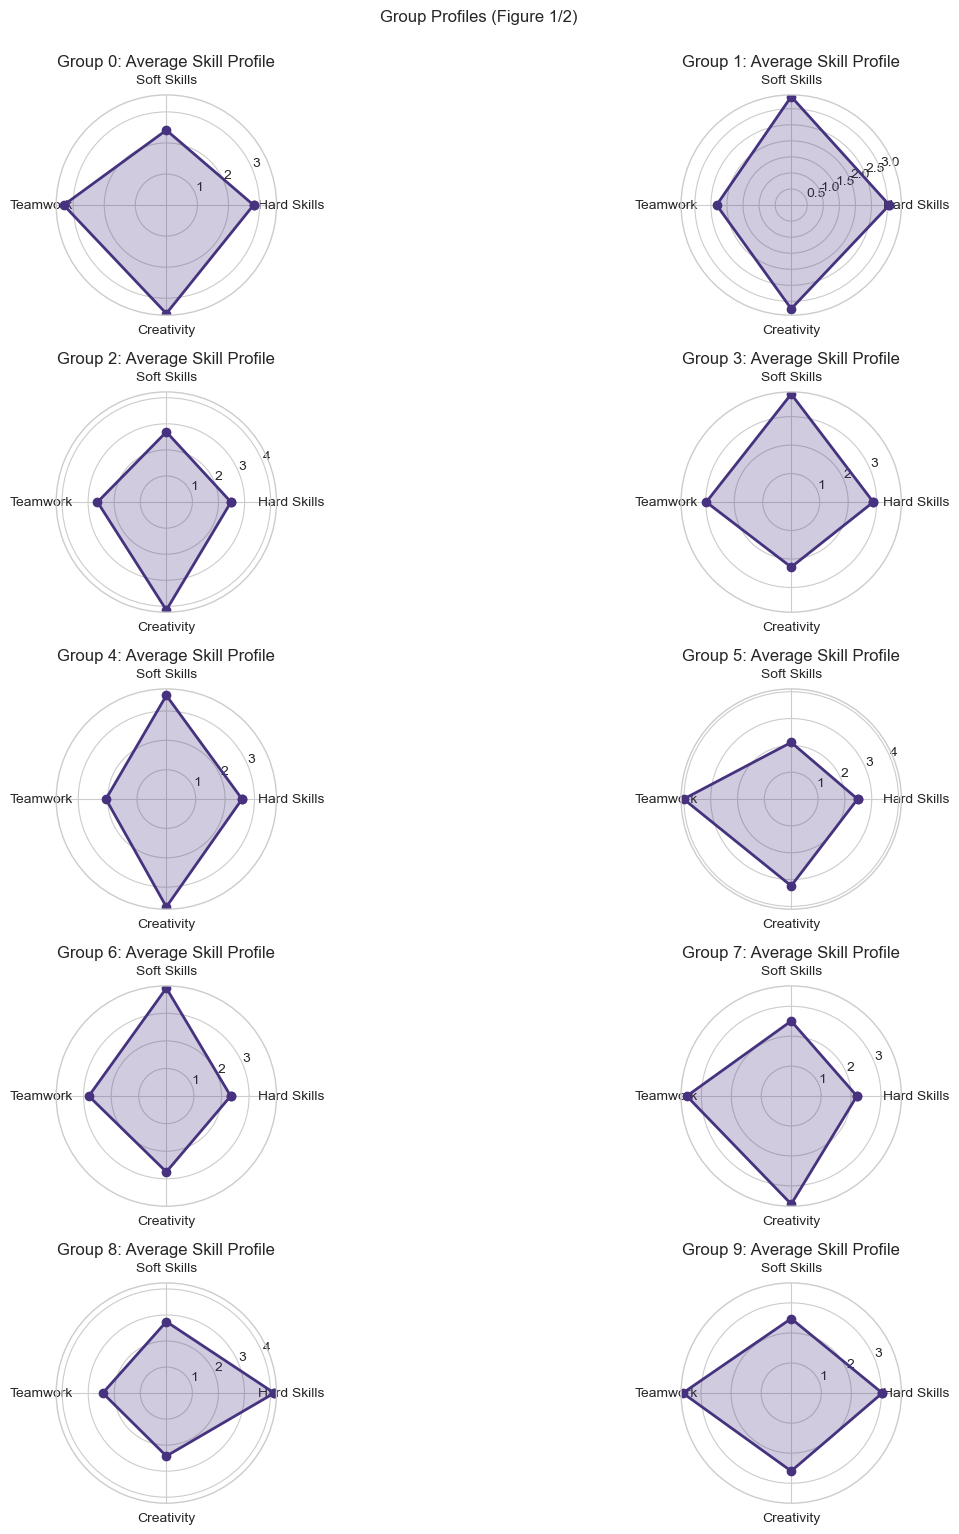

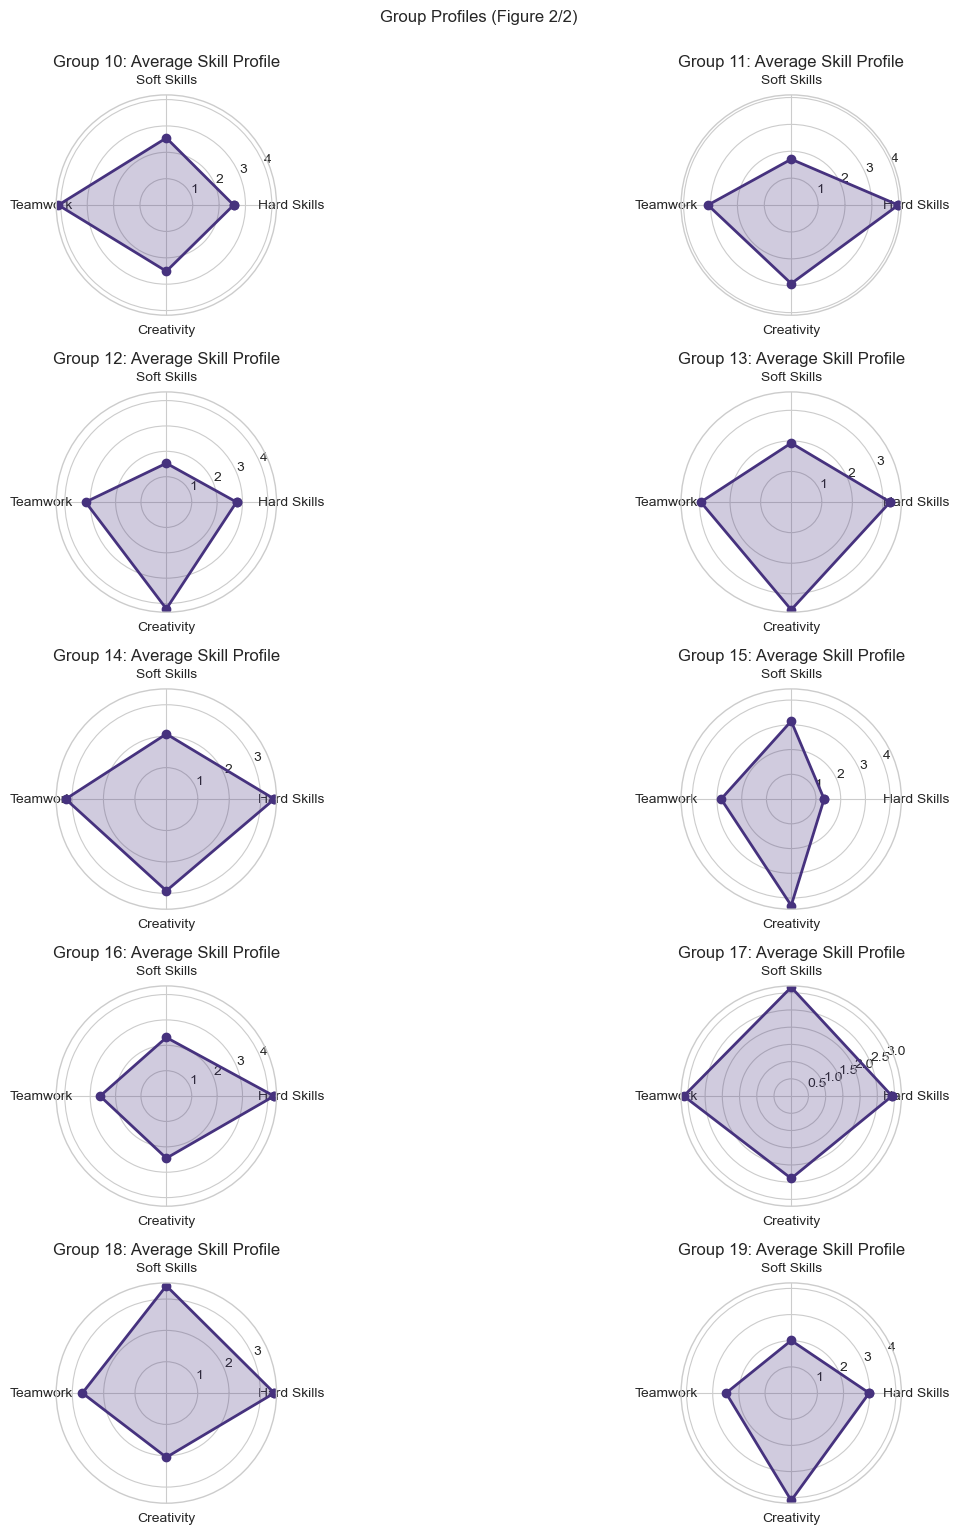

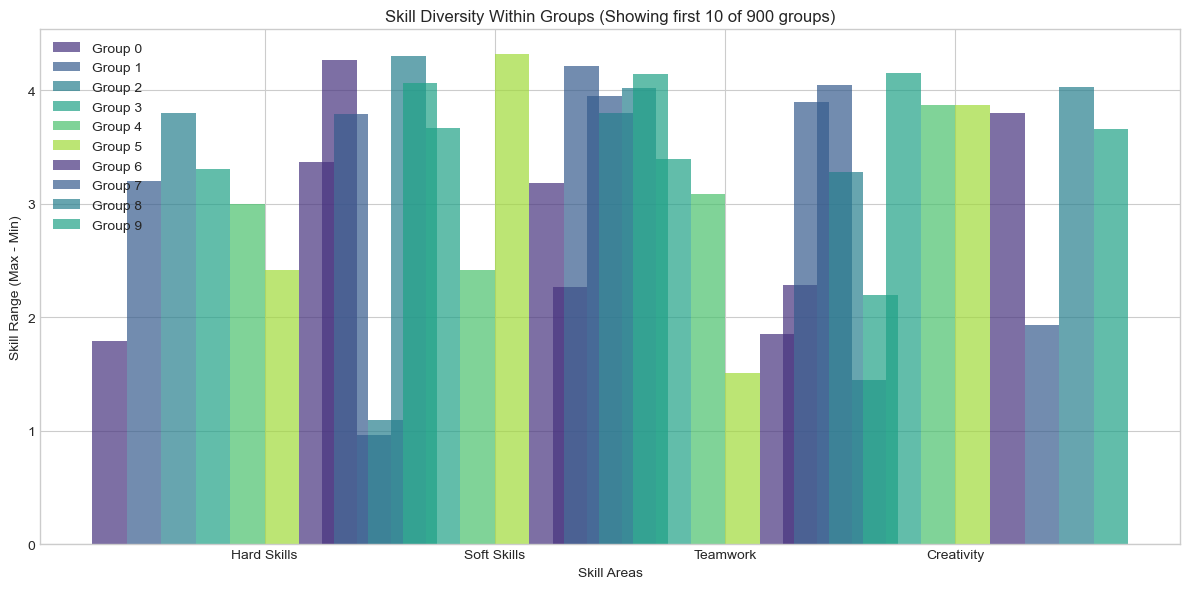


Detailed group profiles:

Summary of all groups:


,Group ID,Size,Avg Hard Skills,Avg Soft Skills,Avg Teamwork,Avg Creativity
0,0,4,2.8075,2.4125,3.3050,3.4925
1,1,4,3.0550,3.3775,2.3225,3.2300
2,2,4,2.4775,2.6900,2.6400,4.1400
3,3,4,2.8825,3.7925,2.9825,2.2850
4,4,4,2.5775,3.5275,2.0575,3.6700
...,...,...,...,...,...,...
895,895,4,2.3750,1.9950,1.2350,2.2900
896,896,4,2.1700,2.0900,2.9575,0.6300
897,897,4,2.1325,2.3775,0.7300,2.4750
898,898,4,1.3750,2.0150,2.1400,2.1650



Detailed profiles for first 5 groups:

Group 0 (4 members):
  Average skill profile:
    - Hard Skills: 2.81 (Range: 1.83 - 3.62)
    - Soft Skills: 2.41 (Range: 0.63 - 4.90)
    - Teamwork: 3.31 (Range: 2.66 - 4.93)
    - Creativity: 3.49 (Range: 2.49 - 4.77)

  Group members:


,overall_skill,dominant_skill,weakest_skill,hard_skills,soft_skills,teamwork,creativity
0,4.5550,teamwork,hard_skills,3.62,4.90,4.93,4.77
900,2.9725,creativity,soft_skills,3.57,1.68,2.74,3.90
1800,2.4925,teamwork,hard_skills,1.83,2.44,2.89,2.81
2700,1.9975,teamwork,soft_skills,2.21,0.63,2.66,2.49



--------------------------------------------------------------------------------

Group 1 (4 members):
  Average skill profile:
    - Hard Skills: 3.05 (Range: 1.61 - 4.81)
    - Soft Skills: 3.38 (Range: 2.88 - 3.84)
    - Teamwork: 2.32 (Range: 0.55 - 4.50)
    - Creativity: 3.23 (Range: 0.91 - 4.96)

  Group members:


...


Average skill range within groups (higher = more diverse):


hard_skills    3.103711
soft_skills    3.072167
teamwork       3.049233
creativity     3.025478
dtype: float64


Overall group heterogeneity assessment:
- Average within-group skill diversity: 3.06 (higher = more diverse)
- Cross-group skill variation: 0.67 (lower = more balanced)
✅ Groups have good internal diversity (complementary skills)
⚠️ There may be imbalance between group average skill levels

MIXED method (cluster-based assignment):
Forming 900 groups of 4 students each
Using MIXED grouping method: Combining cluster-based and skill-based assignment
Analysis of 900 formed groups:
Group sizes: [4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4,

,hard_skills,soft_skills,teamwork,creativity,group
0,3.0275,4.1625,4.8950,3.9125,0
1,3.5100,4.0400,4.2900,3.9950,1
2,3.7650,3.8525,4.3350,3.7750,2
3,3.5000,3.5425,4.5350,4.0700,3
4,3.3675,3.7825,4.2800,4.0650,4
...,...,...,...,...,...
895,0.6050,0.5875,0.3500,1.2300,895
896,1.0700,0.7425,0.3475,0.4825,896
897,0.2950,0.8375,0.5550,0.6875,897
898,0.7725,0.4875,0.3700,0.3300,898


Creating multiple figures to display 900 groups (showing 10 per figure)


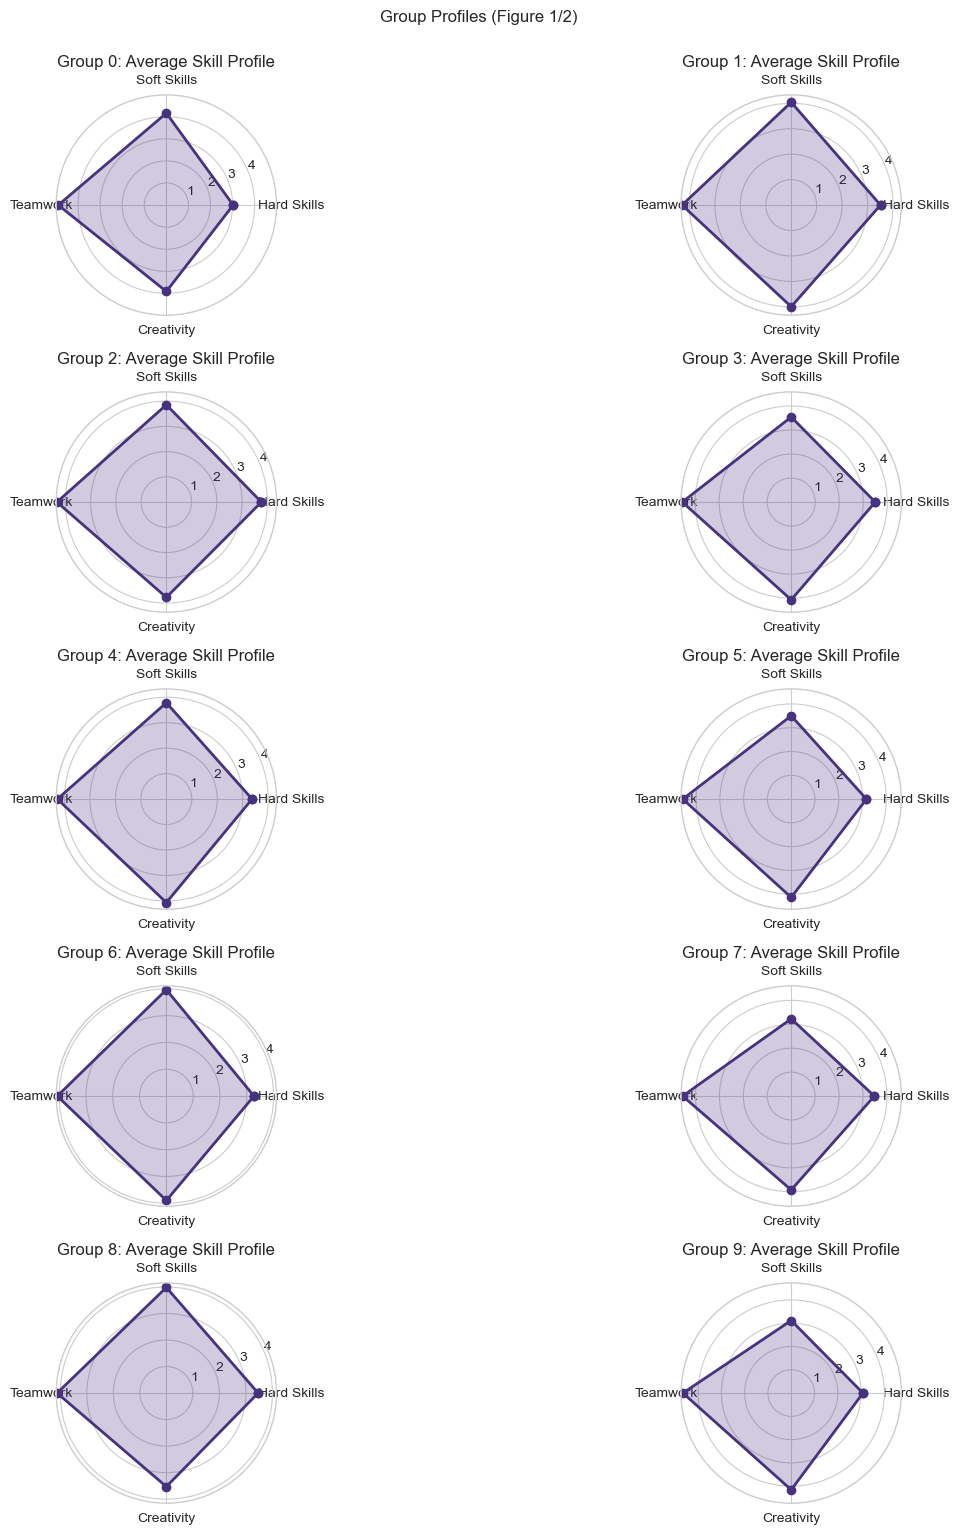

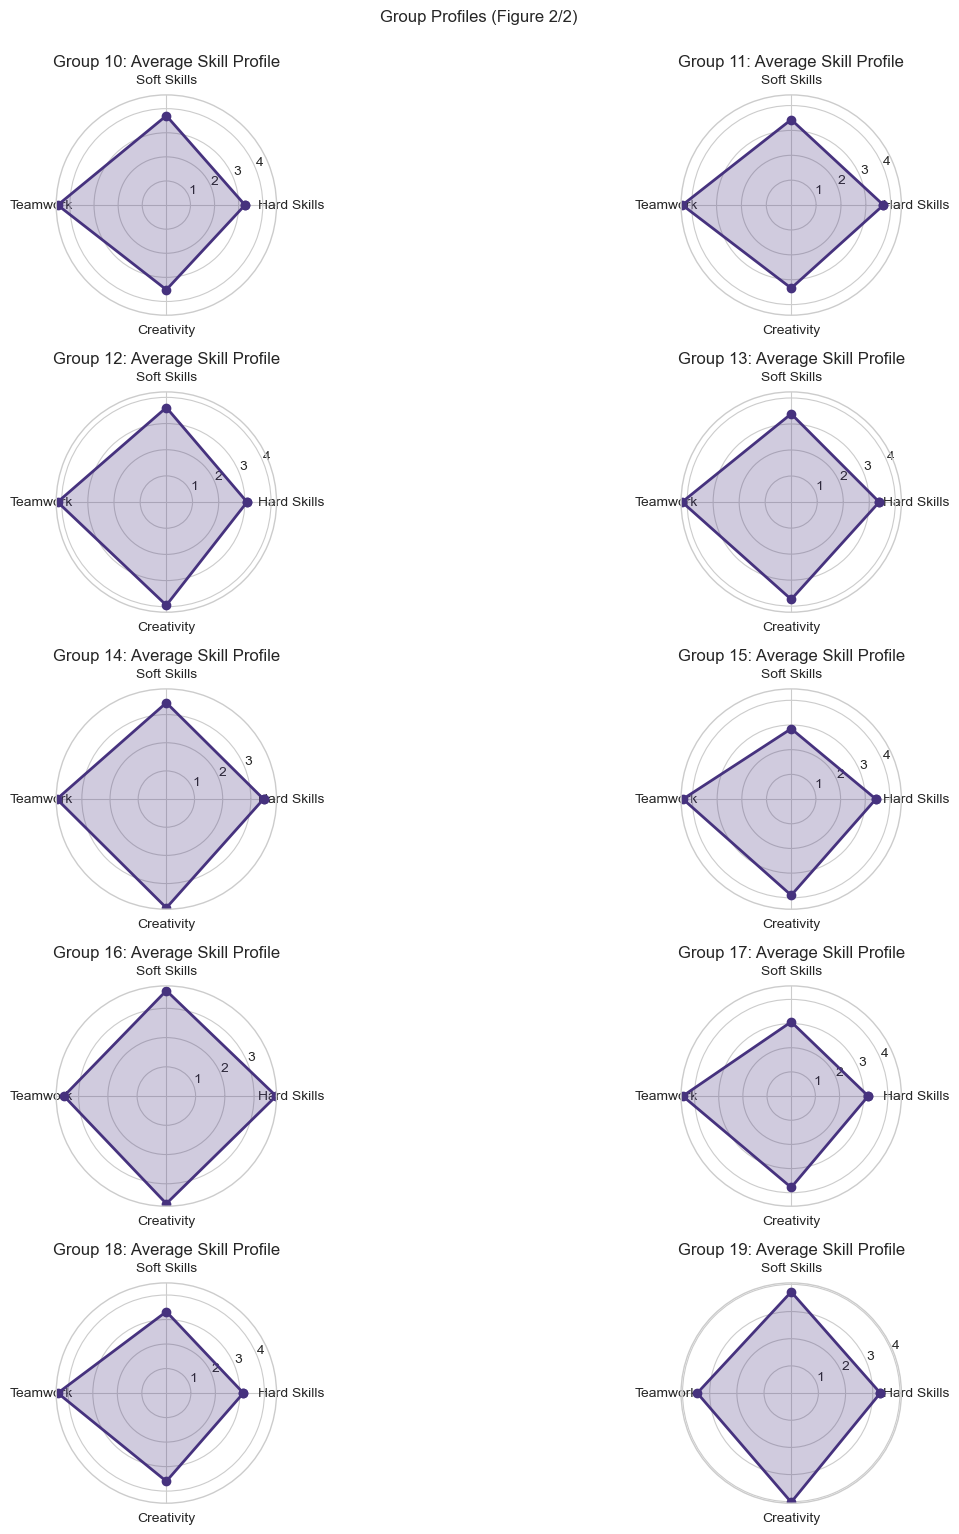

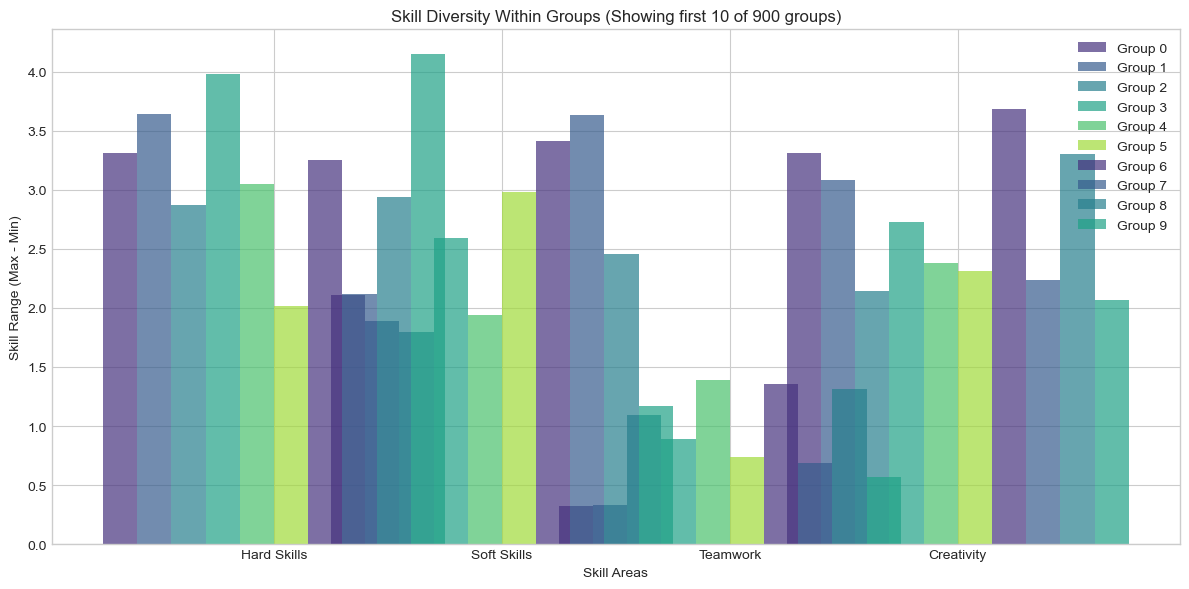


Detailed group profiles:

Summary of all groups:


,Group ID,Size,Avg Hard Skills,Avg Soft Skills,Avg Teamwork,Avg Creativity
0,0,4,3.0275,4.1625,4.8950,3.9125
1,1,4,3.5100,4.0400,4.2900,3.9950
2,2,4,3.7650,3.8525,4.3350,3.7750
3,3,4,3.5000,3.5425,4.5350,4.0700
4,4,4,3.3675,3.7825,4.2800,4.0650
...,...,...,...,...,...,...
895,895,4,0.6050,0.5875,0.3500,1.2300
896,896,4,1.0700,0.7425,0.3475,0.4825
897,897,4,0.2950,0.8375,0.5550,0.6875
898,898,4,0.7725,0.4875,0.3700,0.3300



Detailed profiles for first 5 groups:

Group 0 (4 members):
  Average skill profile:
    - Hard Skills: 3.03 (Range: 0.90 - 4.21)
    - Soft Skills: 4.16 (Range: 2.84 - 4.95)
    - Teamwork: 4.89 (Range: 4.68 - 5.00)
    - Creativity: 3.91 (Range: 1.46 - 4.77)

  Group members:


,overall_skill,dominant_skill,weakest_skill,hard_skills,soft_skills,teamwork,creativity
1772,4.1825,creativity,hard_skills,3.38,3.96,4.68,4.71
2757,3.0700,teamwork,hard_skills,0.90,4.95,4.97,1.46
1564,4.5550,teamwork,hard_skills,3.62,4.90,4.93,4.77
1620,4.1900,teamwork,soft_skills,4.21,2.84,5.00,4.71



--------------------------------------------------------------------------------

Group 1 (4 members):
  Average skill profile:
    - Hard Skills: 3.51 (Range: 1.17 - 4.81)
    - Soft Skills: 4.04 (Range: 2.96 - 4.85)
    - Teamwork: 4.29 (Range: 4.17 - 4.50)
    - Creativity: 4.00 (Range: 1.88 - 4.96)

  Group members:


...


--------------------------------------------------------------------------------

... and 895 more groups (not shown in detail)
Use the summary table above to see average skill levels for all groups.

Group balance analysis:
Standard deviation of average skill levels across groups:


hard_skills    0.605714
soft_skills    0.726883
teamwork       1.080524
creativity     0.700557
dtype: float64


Average skill range within groups (higher = more diverse):


hard_skills    3.123822
soft_skills    2.991989
teamwork       2.174200
creativity     3.038122
dtype: float64


Overall group heterogeneity assessment:
- Average within-group skill diversity: 2.83 (higher = more diverse)
- Cross-group skill variation: 0.78 (lower = more balanced)
✅ Groups have good internal diversity (complementary skills)
⚠️ There may be imbalance between group average skill levels


In [9]:
# Function to form heterogeneous student groups
def form_heterogeneous_groups(df, skill_columns, group_size=4, method='complementary'):
    """
    Form heterogeneous student groups with complementary skills.
    
    Args:
        df: DataFrame with student data and cluster assignments
        skill_columns: List of skill columns
        group_size: Target size for each group
        method: Method for forming groups ('complementary', 'balanced', or 'mixed')
    
    Returns:
        Dictionary of groups and their member information
    """
    # Create a working copy
    students = df.copy()
    
    # Shuffle the students to ensure randomness in selection
    students = students.sample(frac=1, random_state=42).reset_index(drop=True)
    
    # Calculate number of groups
    n_students = len(students)
    n_groups = n_students // group_size
    remainder = n_students % group_size
    
    print(f"Forming {n_groups} groups of {group_size} students each", end="")
    if remainder > 0:
        print(f" (with {remainder} remaining students)")
    else:
        print()
        
    # Initialize groups
    groups = {}
    
    if method == 'complementary':
        print("Using COMPLEMENTARY grouping method: Pairing students with complementary skills")
        
        # Sort students by overall skill level
        students = students.sort_values('overall_skill', ascending=False).reset_index(drop=True)
        
        # For each group, select students with diverse skill strengths
        for g in range(n_groups):
            group_members = []
            
            # Start with students that have different dominant skills
            remaining_students = students[~students.index.isin([m for group in groups.values() for m in group])]
            
            # Select first student (highest overall skill not yet assigned)
            if len(remaining_students) > 0:
                first_student_idx = remaining_students.index[0]
                group_members.append(first_student_idx)
                first_student = remaining_students.loc[first_student_idx]
                
                # Find students with complementary skills
                for _ in range(1, group_size):
                    if len(remaining_students) <= 1:
                        break
                        
                    # Remove already selected students
                    remaining_students = students[~students.index.isin([m for group in groups.values() for m in group] + group_members)]
                    
                    if len(remaining_students) == 0:
                        break
                        
                    # Create a compatibility score - higher for students with strengths
                    # where the current group is weak
                    compatibility_scores = []
                    
                    # Get current group skill profile
                    current_group_skills = students.loc[group_members, skill_columns].mean()
                    
                    for idx, student in remaining_students.iterrows():
                        # Calculate how complementary this student is to the current group
                        # High score if student is strong where group is weak
                        comp_score = 0
                        for skill in skill_columns:
                            # Weighted difference - give higher importance to skills where group is weak
                            weight = 1 + (5 - current_group_skills[skill]) / 5
                            comp_score += weight * (student[skill] - current_group_skills[skill])
                            
                        compatibility_scores.append((idx, comp_score))
                    
                    # Sort by compatibility score (higher is better)
                    compatibility_scores.sort(key=lambda x: x[1], reverse=True)
                    
                    # Add most compatible student to the group
                    if compatibility_scores:
                        group_members.append(compatibility_scores[0][0])
            
            # Store the group
            if group_members:
                groups[g] = group_members
        
    elif method == 'balanced':
        print("Using BALANCED grouping method: Ensuring each group has similar average skill levels")
        
        # Calculate average skill for each student
        students['avg_skill'] = students[skill_columns].mean(axis=1)
        
        # Sort by average skill
        students = students.sort_values('avg_skill', ascending=False).reset_index(drop=True)
        
        # Distribute students so each group has mix of high, medium, and low performers
        for g in range(n_groups):
            group_members = []
            
            # Select one student from each quartile
            for q in range(group_size):
                pos = g + (q * n_groups)
                if pos < len(students):
                    group_members.append(students.index[pos])
            
            groups[g] = group_members
            
    elif method == 'mixed':
        print("Using MIXED grouping method: Combining cluster-based and skill-based assignment")
        
        # Get number of clusters
        n_clusters = students['cluster'].nunique()
        
        # For each group, try to include students from different clusters
        for g in range(n_groups):
            group_members = []
            
            # Try to add one student from each cluster
            for c in range(min(n_clusters, group_size)):
                cluster_students = students[(students['cluster'] == c) & 
                                           (~students.index.isin([m for group in groups.values() for m in group]))]
                
                if len(cluster_students) > 0:
                    # Take the student with highest overall_skill from this cluster
                    student_idx = cluster_students.sort_values('overall_skill', ascending=False).index[0]
                    group_members.append(student_idx)
            
            # If we need more students to reach group_size
            remaining_spots = group_size - len(group_members)
            if remaining_spots > 0:
                # Get remaining students
                remaining_students = students[~students.index.isin([m for group in groups.values() for m in group] + group_members)]
                
                # Sort by overall skill (descending)
                remaining_students = remaining_students.sort_values('overall_skill', ascending=False)
                
                # Add top students
                for i in range(min(remaining_spots, len(remaining_students))):
                    group_members.append(remaining_students.index[i])
            
            groups[g] = group_members
    
    else:
        raise ValueError(f"Unknown grouping method: {method}")
    
    # Handle remaining students by adding them to existing groups
    remaining_students = students[~students.index.isin([m for group in groups.values() for m in group])]
    
    for i, idx in enumerate(remaining_students.index):
        if i < len(groups):
            groups[i].append(idx)
    
    # Convert group indices to actual student data
    groups_data = {}
    for g, member_indices in groups.items():
        group_df = students.loc[member_indices].copy()
        groups_data[g] = {
            'members': group_df,
            'size': len(group_df),
            'avg_skills': group_df[skill_columns].mean().to_dict(),
            'min_skills': group_df[skill_columns].min().to_dict(),
            'max_skills': group_df[skill_columns].max().to_dict(),
            'skill_range': (group_df[skill_columns].max() - group_df[skill_columns].min()).to_dict()
        }
    
    return groups_data

# Function to analyze and visualize the formed groups
def analyze_groups(groups, skill_columns):
    """
    Analyze and visualize the formed groups.
    """
    n_groups = len(groups)
    print(f"Analysis of {n_groups} formed groups:")
    
    # 1. Summary statistics for all groups
    group_sizes = [data['size'] for data in groups.values()]
    print(f"Group sizes: {group_sizes}")
    
    # Create a DataFrame with group averages
    group_avgs = pd.DataFrame([data['avg_skills'] for data in groups.values()])
    group_avgs['group'] = list(groups.keys())
    
    # Calculate skill ranges in each group
    group_ranges = pd.DataFrame([data['skill_range'] for data in groups.values()])
    group_ranges['group'] = list(groups.keys())
    
    # Display average skill profiles for each group
    print("\nAverage skill profiles for each group:")
    display(group_avgs)
    
    # 2. Radar charts for group average profiles
    # Limit the number of charts to avoid excessive figure size
    max_groups_to_display = min(n_groups, 20)  # Display at most 20 groups to avoid memory issues
    
    if max_groups_to_display <= 10:
        # For a small number of groups, display all in one figure
        fig_rows = (max_groups_to_display + 1) // 2
        fig, axes = plt.subplots(nrows=fig_rows, ncols=min(2, max_groups_to_display), 
                               figsize=(15, 3*fig_rows), subplot_kw={'polar': True})
        
        # Handle the case of a single subplot
        if max_groups_to_display == 1:
            axes = np.array([axes])
        
        # Ensure axes is always a flattened array
        axes = np.atleast_1d(axes).flatten()
        
        for i, (group_id, data) in enumerate(list(groups.items())[:max_groups_to_display]):
            # Get the group's average skill profile
            avg_profile = [data['avg_skills'][skill] for skill in skill_columns]
            
            # Close the loop for the radar chart
            values = np.append(avg_profile, avg_profile[0])
            
            # Angles for the radar chart
            angles = np.linspace(0, 2*np.pi, len(skill_columns), endpoint=False).tolist()
            angles += angles[:1]  # Close the loop
            
            # Labels (prettify column names)
            labels = [col.replace('_', ' ').title() for col in skill_columns]
            labels += labels[:1]  # Close the loop
            
            # Plot the radar chart
            axes[i].plot(angles, values, 'o-', linewidth=2)
            axes[i].fill(angles, values, alpha=0.25)
            axes[i].set_thetagrids(np.degrees(angles[:-1]), labels[:-1])
            axes[i].set_title(f'Group {group_id}: Average Skill Profile', size=12)
        
        # Hide any unused subplots
        for i in range(max_groups_to_display, len(axes)):
            axes[i].axis('off')
        
        plt.tight_layout()
        plt.show()
    else:
        # For many groups, create multiple figures with at most 10 groups each
        print(f"Creating multiple figures to display {n_groups} groups (showing 10 per figure)")
        
        for fig_num, group_offset in enumerate(range(0, max_groups_to_display, 10)):
            groups_in_figure = min(10, max_groups_to_display - group_offset)
            fig_rows = (groups_in_figure + 1) // 2
            
            fig, axes = plt.subplots(nrows=fig_rows, ncols=min(2, groups_in_figure), 
                                   figsize=(15, 3*fig_rows), subplot_kw={'polar': True})
            
            # Ensure axes is always a flattened array
            axes = np.atleast_1d(axes).flatten()
            
            for i in range(groups_in_figure):
                group_index = group_offset + i
                group_id = list(groups.keys())[group_index]
                data = groups[group_id]
                
                # Get the group's average skill profile
                avg_profile = [data['avg_skills'][skill] for skill in skill_columns]
                
                # Close the loop for the radar chart
                values = np.append(avg_profile, avg_profile[0])
                
                # Angles for the radar chart
                angles = np.linspace(0, 2*np.pi, len(skill_columns), endpoint=False).tolist()
                angles += angles[:1]  # Close the loop
                
                # Labels (prettify column names)
                labels = [col.replace('_', ' ').title() for col in skill_columns]
                labels += labels[:1]  # Close the loop
                
                # Plot the radar chart
                axes[i].plot(angles, values, 'o-', linewidth=2)
                axes[i].fill(angles, values, alpha=0.25)
                axes[i].set_thetagrids(np.degrees(angles[:-1]), labels[:-1])
                axes[i].set_title(f'Group {group_id}: Average Skill Profile', size=12)
            
            # Hide any unused subplots
            for i in range(groups_in_figure, len(axes)):
                axes[i].axis('off')
            
            plt.tight_layout()
            plt.suptitle(f'Group Profiles (Figure {fig_num+1}/{(max_groups_to_display+9)//10})', y=1.02)
            plt.show()
    
    # 3. Skill range within groups (max - min)
    # Limit the number of groups to display in the bar chart
    max_groups_to_plot = min(10, n_groups)  # Display at most 10 groups in the bar chart
    
    plt.figure(figsize=(12, 6))
    
    # Set width of bars
    bar_width = 0.15
    
    # Set position of bars on x axis
    positions = np.arange(len(skill_columns))
    
    # Plot bars for each group's skill range (limited to max_groups_to_plot)
    for i, group_id in enumerate(list(groups.keys())[:max_groups_to_plot]):
        ranges = [groups[group_id]['skill_range'][skill] for skill in skill_columns]
        plt.bar(positions + i*bar_width, ranges, bar_width, 
                alpha=0.7, label=f'Group {group_id}')
    
    # Add labels and title
    plt.xlabel('Skill Areas')
    plt.ylabel('Skill Range (Max - Min)')
    plt.title(f'Skill Diversity Within Groups (Showing first {max_groups_to_plot} of {n_groups} groups)')
    plt.xticks(positions + bar_width * (min(max_groups_to_plot, n_groups)-1) / 2, 
               [col.replace('_', ' ').title() for col in skill_columns])
    
    # Only show legend if there are not too many groups
    if max_groups_to_plot <= 10:
        plt.legend()
    else:
        plt.legend().set_visible(False)
        
    plt.grid(True, axis='y')
    plt.tight_layout()
    plt.show()
    
    # 4. Detailed group profiles
    print("\nDetailed group profiles:")
    
    # Limit the number of groups to display in detail
    max_groups_to_display_detail = min(5, n_groups)  # Display details for at most 5 groups
    
    # Create summary table for all groups
    summary_data = []
    for group_id, data in groups.items():
        group_summary = {'Group ID': group_id, 'Size': data['size']}
        # Add average scores for each skill
        for skill in skill_columns:
            group_summary[f'Avg {skill.replace("_", " ").title()}'] = data['avg_skills'][skill]
        summary_data.append(group_summary)
    
    # Display summary table for all groups
    print("\nSummary of all groups:")
    summary_df = pd.DataFrame(summary_data)
    display(summary_df)
    
    # Display detailed information for a limited number of groups
    print(f"\nDetailed profiles for first {max_groups_to_display_detail} groups:")
    
    for group_id in list(groups.keys())[:max_groups_to_display_detail]:
        data = groups[group_id]
        print(f"\nGroup {group_id} ({data['size']} members):")
        print("  Average skill profile:")
        for skill in skill_columns:
            print(f"    - {skill.replace('_', ' ').title()}: {data['avg_skills'][skill]:.2f} (Range: {data['min_skills'][skill]:.2f} - {data['max_skills'][skill]:.2f})")
        
        # Print group members
        print("\n  Group members:")
        member_df = data['members'][['overall_skill', 'dominant_skill', 'weakest_skill'] + skill_columns]
        display(member_df)
        print("\n" + "-"*80)
    
    # If there are more groups than we're displaying in detail
    if n_groups > max_groups_to_display_detail:
        print(f"\n... and {n_groups - max_groups_to_display_detail} more groups (not shown in detail)")
        print(f"Use the summary table above to see average skill levels for all groups.")
    
    # 5. Group balance analysis
    print("\nGroup balance analysis:")
    
    # Calculate standard deviation across groups for each skill
    group_std = pd.DataFrame([data['avg_skills'] for data in groups.values()]).std()
    print("Standard deviation of average skill levels across groups:")
    display(group_std)
    
    # Calculate average skill range within groups
    avg_range = group_ranges[skill_columns].mean()
    print("\nAverage skill range within groups (higher = more diverse):")
    display(avg_range)
    
    # Overall assessment
    print("\nOverall group heterogeneity assessment:")
    avg_range_score = avg_range.mean()
    cross_group_std = group_std.mean()
    
    print(f"- Average within-group skill diversity: {avg_range_score:.2f} (higher = more diverse)")
    print(f"- Cross-group skill variation: {cross_group_std:.2f} (lower = more balanced)")
    
    if avg_range_score > 1.5:
        print("✅ Groups have good internal diversity (complementary skills)")
    else:
        print("⚠️ Groups may have limited internal diversity")
        
    if cross_group_std < 0.5:
        print("✅ Groups have similar average skill levels (fair distribution)")
    else:
        print("⚠️ There may be imbalance between group average skill levels")

# Apply group formation if we have clustered data
if 'clustered_students' in locals():
    # Form groups using the complementary method
    student_groups = form_heterogeneous_groups(clustered_students, skill_cols, 
                                              group_size=4, method='complementary')
    
    # Analyze the formed groups
    analyze_groups(student_groups, skill_cols)
    
    # Also form groups using alternative methods for comparison
    print("\n" + "="*80)
    print("Alternative grouping methods for comparison:")
    
    print("\n" + "="*80)
    print("BALANCED method (similar average skill levels):")
    balanced_groups = form_heterogeneous_groups(clustered_students, skill_cols, 
                                             group_size=4, method='balanced')
    analyze_groups(balanced_groups, skill_cols)
    
    print("\n" + "="*80)
    print("MIXED method (cluster-based assignment):")
    mixed_groups = form_heterogeneous_groups(clustered_students, skill_cols, 
                                          group_size=4, method='mixed')
    analyze_groups(mixed_groups, skill_cols)

## 5. Group Project Recommendations

Based on the groups formed and their skill compositions, we can provide recommendations for project types or roles that might be well-suited for each group.

In [10]:
# Function to generate project recommendations for groups
def recommend_projects_and_roles(groups, skill_columns):
    """
    Generate project type and role recommendations for each group.
    """
    print("Generating group project recommendations and role suggestions...")
    
    # Project types based on group skill profiles
    project_types = {
        'high_technical': "Technical development project requiring strong hard skills",
        'high_creative': "Innovation-focused project requiring creative problem solving",
        'high_teamwork': "Complex collaborative project requiring effective team coordination",
        'high_soft_skills': "Client-facing project requiring strong communication and leadership",
        'balanced': "Multifaceted project requiring balanced application of various skills"
    }
    
    # Define role templates
    role_templates = {
        'technical_lead': "Technical implementation and problem-solving",
        'creative_director': "Idea generation and innovative solutions", 
        'team_coordinator': "Task management and team coordination",
        'client_liaison': "Client communication and presentation"
    }
    
    for group_id, data in groups.items():
        print(f"\nGroup {group_id} - Recommendations:")
        
        # Get group average skills
        avg_skills = data['avg_skills']
        
        # Determine group's overall strength
        top_skill = max(avg_skills, key=avg_skills.get)
        top_skill_score = avg_skills[top_skill]
        
        # Determine if the group is balanced or has a clear strength
        skill_values = list(avg_skills.values())
        skill_std = np.std(skill_values)
        
        # Recommend project type
        if skill_std < 0.5:  # Balanced group
            recommended_project = project_types['balanced']
            print(f"📋 Recommended Project Type: {recommended_project}")
            print("   This group has a balanced skill profile and should handle diverse project requirements well.")
        else:  # Group with specific strengths
            if 'hard_skills' in avg_skills and avg_skills['hard_skills'] > 4:
                recommended_project = project_types['high_technical']
            elif 'creativity' in avg_skills and avg_skills['creativity'] > 4:
                recommended_project = project_types['high_creative']
            elif 'teamwork' in avg_skills and avg_skills['teamwork'] > 4:
                recommended_project = project_types['high_teamwork']
            elif 'soft_skills' in avg_skills and avg_skills['soft_skills'] > 4:
                recommended_project = project_types['high_soft_skills']
            else:
                recommended_project = project_types['balanced']
                
            print(f"📋 Recommended Project Type: {recommended_project}")
            print(f"   This group shows particular strength in {top_skill.replace('_', ' ').title()} ({top_skill_score:.2f}/5)")
        
        # Suggest roles for each group member based on individual strengths
        print("\n   Suggested role assignments:")
        
        for i, (idx, student) in enumerate(data['members'].iterrows(), 1):
            # Find student's top skill
            student_skills = {skill: student[skill] for skill in skill_columns}
            top_student_skill = max(student_skills, key=student_skills.get)
            
            # Assign role based on top skill
            if 'hard_skills' in student_skills and top_student_skill == 'hard_skills':
                role = role_templates['technical_lead']
            elif 'creativity' in student_skills and top_student_skill == 'creativity':
                role = role_templates['creative_director']
            elif 'teamwork' in student_skills and top_student_skill == 'teamwork':
                role = role_templates['team_coordinator']
            elif 'soft_skills' in student_skills and top_student_skill == 'soft_skills':
                role = role_templates['client_liaison']
            else:
                # Determine role based on relative strengths
                if 'student_id' in student:
                    student_name = f"Student {student['student_id']}"
                else:
                    student_name = f"Student {idx}"
                
                strengths = []
                if student.get('hard_skills', 0) > 3.5:
                    strengths.append('technical')
                if student.get('creativity', 0) > 3.5:
                    strengths.append('creative')
                if student.get('teamwork', 0) > 3.5:
                    strengths.append('teamwork')
                if student.get('soft_skills', 0) > 3.5:
                    strengths.append('communication')
                
                if not strengths:
                    strengths = ['supportive']
                    
                role = f"General support with focus on {', '.join(strengths)} tasks"
            
            # Print the role suggestion
            if 'student_id' in student:
                student_name = f"Student {student['student_id']}"
            elif 'name' in student:
                student_name = student['name']
            else:
                student_name = f"Student {idx}"
                
            print(f"   - {student_name}: {role} (Strength: {top_student_skill.replace('_', ' ').title()})")
        
        print(f"\n   Key development areas for this group:")
        # Identify the group's weakest skill
        weakest_skill = min(avg_skills, key=avg_skills.get)
        print(f"   - Focus on developing {weakest_skill.replace('_', ' ').title()} ({avg_skills[weakest_skill]:.2f}/5)")
        
        # Additional recommendations based on skill distribution
        if skill_std > 1.0:
            print(f"   - Be aware of significant skill disparities within the group")
            print(f"   - Consider peer mentoring for knowledge sharing")
        
        # Identify if there are any critical gaps (all members weak in same area)
        critical_gaps = []
        for skill in skill_columns:
            if data['max_skills'][skill] < 3.0:  # No one in group is strong in this area
                critical_gaps.append(skill)
                
        if critical_gaps:
            print(f"   - Critical gaps: No team member is strong in {', '.join([g.replace('_', ' ').title() for g in critical_gaps])}")
            print(f"   - Consider seeking external support or focused training in these areas")

# Generate recommendations if we have formed groups
if 'student_groups' in locals():
    recommend_projects_and_roles(student_groups, skill_cols)

Generating group project recommendations and role suggestions...

Group 0 - Recommendations:
📋 Recommended Project Type: Multifaceted project requiring balanced application of various skills
   This group has a balanced skill profile and should handle diverse project requirements well.

   Suggested role assignments:
   - Student 0: Task management and team coordination (Strength: Teamwork)
   - Student 1: Idea generation and innovative solutions (Strength: Creativity)
   - Student 2: Task management and team coordination (Strength: Teamwork)
   - Student 3: Client communication and presentation (Strength: Soft Skills)

   Key development areas for this group:
   - Focus on developing Creativity (4.39/5)

Group 1 - Recommendations:
📋 Recommended Project Type: Multifaceted project requiring balanced application of various skills
   This group has a balanced skill profile and should handle diverse project requirements well.

   Suggested role assignments:
   - Student 4: Idea generation 

## 6. Exporting Results

Finally, let's export the formed groups and their analysis to a format that can be easily shared and referenced.

In [11]:
# Function to export groups to CSV
def export_groups_to_csv(groups, output_folder='data', filename='student_groups.csv'):
    """
    Export the formed groups to a CSV file.
    """
    # Create output folder if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)
    
    # Create output path
    output_path = os.path.join(output_folder, filename)
    
    # Create a list to store all group data
    all_group_data = []
    
    for group_id, data in groups.items():
        # Add group ID to each student record
        group_df = data['members'].copy()
        group_df['group_id'] = group_id
        
        # Add to the list
        all_group_data.append(group_df)
    
    # Combine all groups
    if all_group_data:
        combined_df = pd.concat(all_group_data, ignore_index=True)
        
        # Save to CSV
        combined_df.to_csv(output_path, index=False)
        print(f"✅ Exported group assignments to: {output_path}")
        
        return output_path
    else:
        print("❌ No group data to export")
        return None

# Export the groups if we have them
if 'student_groups' in locals():
    export_path = export_groups_to_csv(student_groups)
    
    if export_path:
        # Display a sample of the exported data
        exported_df = pd.read_csv(export_path)
        print("\nSample of exported group assignments:")
        display(exported_df.head())

✅ Exported group assignments to: data\student_groups.csv

Sample of exported group assignments:


,first_name,last_name,gender,age,nationality,hard_skills,soft_skills,teamwork,creativity,class,...,skill_variance,dominant_skill,weakest_skill,norm_hard_skills,norm_soft_skills,norm_teamwork,norm_creativity,cluster,dbscan_cluster,group_id
0,Asma,Mabrouk,Female,20,Tunisian,3.62,4.90,4.93,4.77,3B11,...,0.393367,teamwork,hard_skills,0.724,0.980,0.986,0.955912,2,0,0
1,Hicham,Regragui,Male,19,Moroccan,4.81,3.84,4.50,4.96,2P81,...,0.246758,creativity,soft_skills,0.962,0.768,0.900,0.993988,2,0,0
2,Hassan,Bennani,Male,18,Moroccan,4.84,4.79,4.98,3.35,1A22,...,0.584067,teamwork,creativity,0.968,0.958,0.996,0.671343,2,0,0
3,Dorra,Cherif,Female,20,Tunisian,4.61,4.79,4.05,4.50,3B16,...,0.099358,soft_skills,teamwork,0.922,0.958,0.810,0.901804,2,0,0
4,Mariem,Guettari,Female,23,Tunisian,4.54,4.73,3.41,4.84,5NIDS51,...,0.433533,creativity,teamwork,0.908,0.946,0.682,0.969940,2,0,1


## 7. Summary and Conclusion

This notebook has demonstrated a systematic approach to creating heterogeneous student groups with complementary skills. The approach follows these key steps:

1. **Data Analysis**: Explored student skill profiles to understand the distribution and relationship between different skill areas.

2. **Skill Pattern Identification**: Used clustering to identify common patterns in student skill profiles.

3. **Heterogeneous Group Formation**: Created balanced groups where students complement each other's strengths and weaknesses.

4. **Group Analysis**: Evaluated the balance and diversity of skills within each formed group.

5. **Project Recommendations**: Provided tailored project and role recommendations based on group composition.

The heterogeneous grouping approach offers several benefits:
- Students can learn from peers with different strengths
- Groups have more balanced overall capabilities
- Skill gaps in individuals can be compensated for by other team members
- Students get exposure to different perspectives and working styles

This approach can be adapted and refined based on specific educational objectives and additional student characteristics.